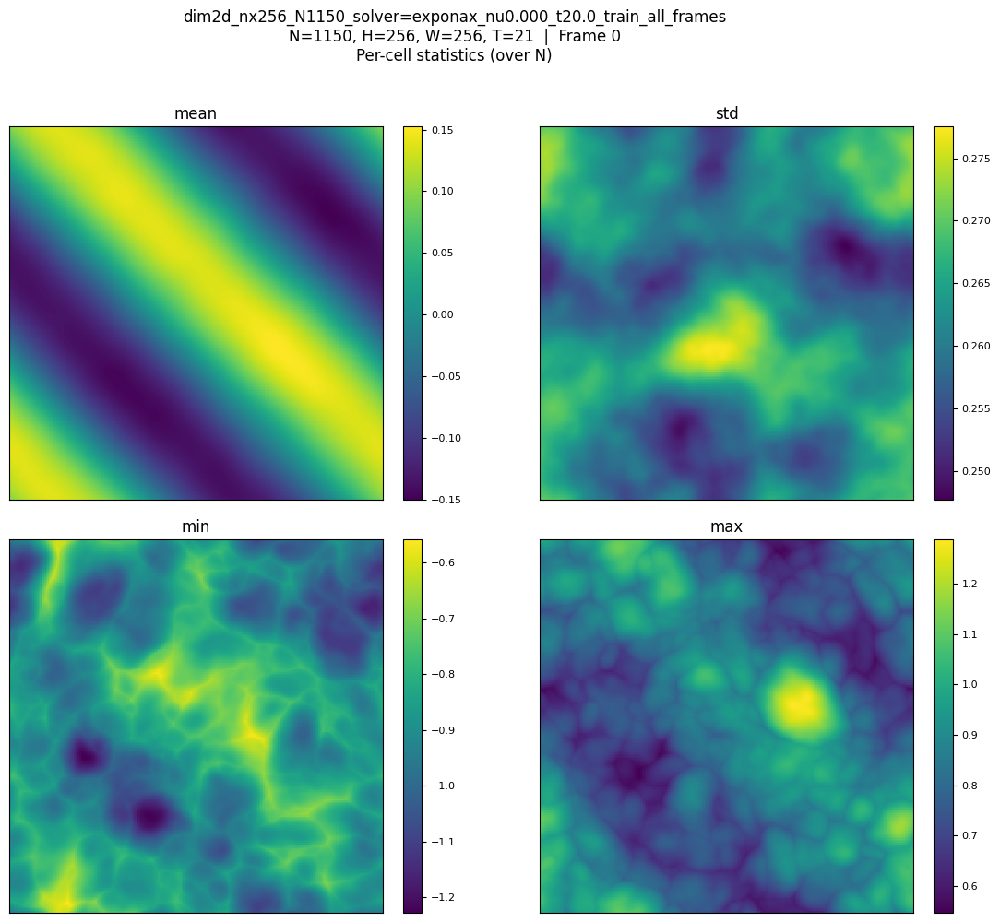

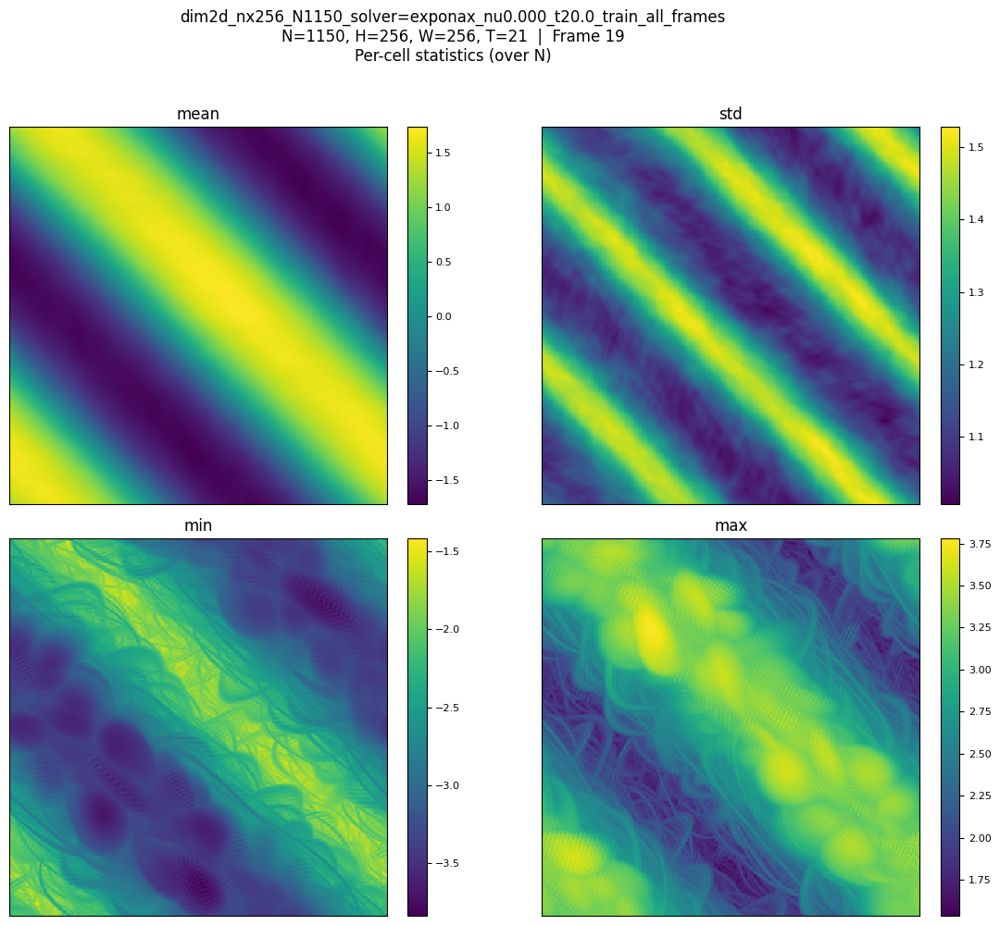

In [1]:
# ---- 在 notebook 里直接运行 ----
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

def _per_cell_stats_from_raw(y_t: torch.Tensor):
    """
    y_t: (N, H, W) torch tensor
    return: dict of HxW numpy arrays: mean, std, min, max
    统计维度是样本维 N（与之前脚本一致）。
    """
    if not torch.is_tensor(y_t) or y_t.ndim != 3:
        raise ValueError(f"expect y_t with shape (N,H,W), got {tuple(y_t.shape)}")
    # to numpy
    A = y_t.contiguous().cpu().numpy().astype(np.float64, copy=False)  # (N,H,W)
    N, H, W = A.shape
    A2D = A.reshape(N, H*W)  # (N, H*W)

    mean = np.nanmean(A2D, axis=0).reshape(H, W).astype(np.float32)
    std  = np.nanstd (A2D, axis=0).reshape(H, W).astype(np.float32)
    vmin = np.nanmin(A2D, axis=0).reshape(H, W).astype(np.float32)
    vmax = np.nanmax(A2D, axis=0).reshape(H, W).astype(np.float32)
    return {"mean": mean, "std": std, "min": vmin, "max": vmax}

def _imshow2d(ax, arr, title):
    im = ax.imshow(arr, origin="lower", interpolation="nearest")
    ax.set_title(title, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

def show_spatial_percell_stats(pt_path, frames=(0,19)):
    """
    只需提供数据集路径 pt_path（.pt 文件，字典里含 'y' : (N,H,W,T)）。
    将分别“显示”两张图（frame0 和 frame19 各一张），不保存。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not isinstance(payload, dict) or "y" not in payload:
        raise ValueError(f"{pt_path.name}: not a dict or missing key 'y'")
    y = payload["y"]
    if not torch.is_tensor(y) or y.ndim != 4:
        raise ValueError(f"{pt_path.name}: y should be (N,H,W,T), got {tuple(y.shape)}")
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    stem = pt_path.stem

    for t in frames:
        if t < 0 or t >= T:
            print(f"[skip] frame {t} out of range 0..{T-1}")
            continue
        y_t = y[..., t]  # (N,H,W)
        stats = _per_cell_stats_from_raw(y_t)

        # 两行两列：mean / std / min / max
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        title_head = f"{stem}\nN={N}, H={H}, W={W}, T={T}  |  Frame {t}\nPer-cell statistics (over N)"
        fig.suptitle(title_head, y=0.995, fontsize=12)

        _imshow2d(axes[0,0], stats["mean"], "mean")
        _imshow2d(axes[0,1], stats["std"],  "std")
        _imshow2d(axes[1,0], stats["min"],  "min")
        _imshow2d(axes[1,1], stats["max"],  "max")

        fig.tight_layout(rect=[0,0,1,0.98])
        plt.show()

# 用法：把路径替换为你的 .pt 文件路径即可
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt")


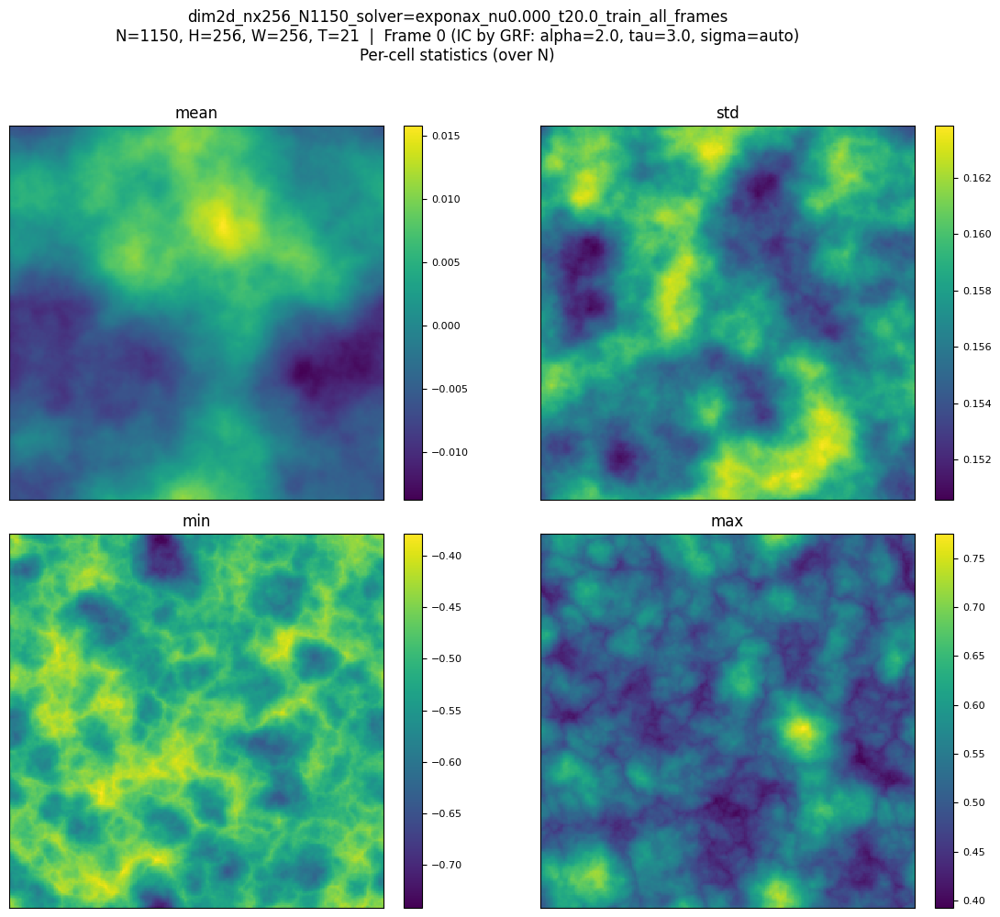

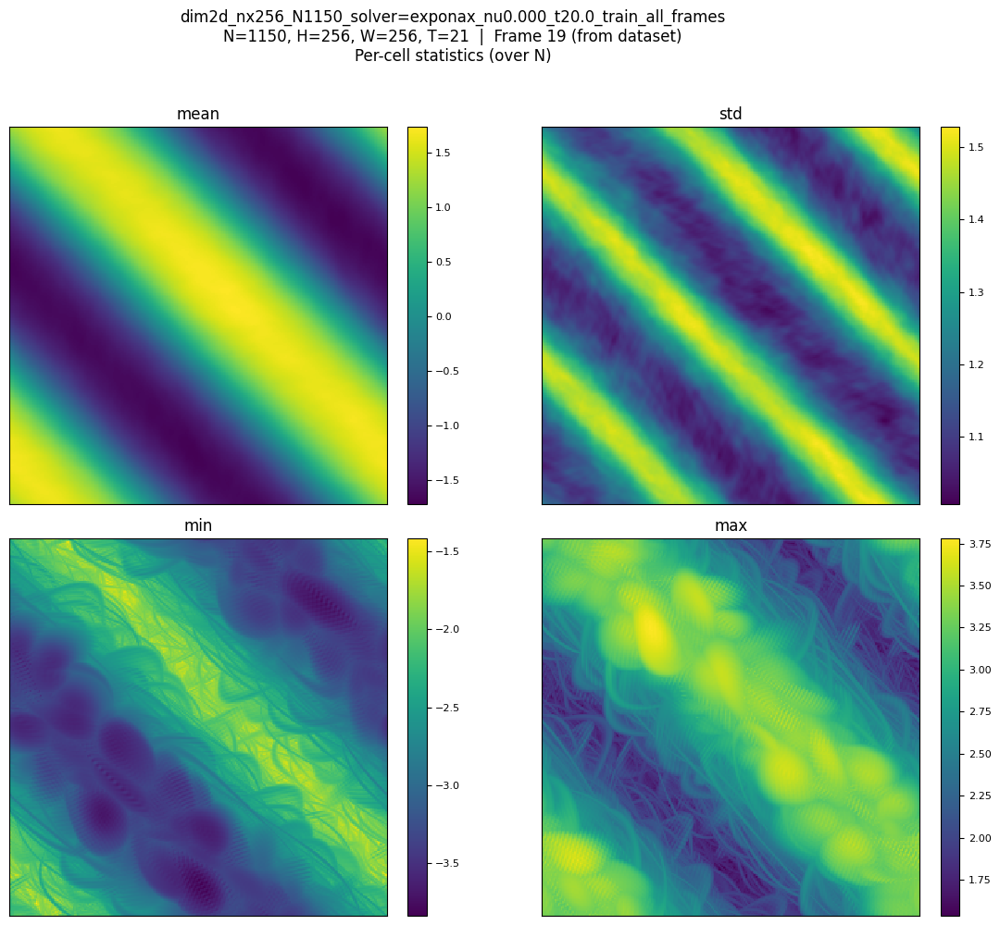

In [1]:
# ---- 在 notebook 里直接运行 ----
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# ========== 你原有的辅助函数：不变 ==========
def _per_cell_stats_from_raw(y_t: torch.Tensor):
    """
    y_t: (N, H, W) torch tensor
    return: dict of HxW numpy arrays: mean, std, min, max
    统计维度是样本维 N。
    """
    if not torch.is_tensor(y_t) or y_t.ndim != 3:
        raise ValueError(f"expect y_t with shape (N,H,W), got {tuple(y_t.shape)}")
    A = y_t.contiguous().cpu().numpy().astype(np.float64, copy=False)  # (N,H,W)
    N, H, W = A.shape
    A2D = A.reshape(N, H*W)  # (N, H*W)

    mean = np.nanmean(A2D, axis=0).reshape(H, W).astype(np.float32)
    std  = np.nanstd (A2D, axis=0).reshape(H, W).astype(np.float32)
    vmin = np.nanmin(A2D, axis=0).reshape(H, W).astype(np.float32)
    vmax = np.nanmax(A2D, axis=0).reshape(H, W).astype(np.float32)
    return {"mean": mean, "std": std, "min": vmin, "max": vmax}

def _imshow2d(ax, arr, title):
    im = ax.imshow(arr, origin="lower", interpolation="nearest")
    ax.set_title(title, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

# ========== 你的 GRF 类：按你提供的版本 ==========
import math
class GaussianRF(object):
    def __init__(self, dim, size, alpha=2, tau=3, sigma=None, boundary="periodic", device=None):
        self.dim = dim
        self.device = device
        if sigma is None:
            sigma = tau**(0.5*(2*alpha - self.dim))
        k_max = size//2

        if dim == 1:
            k = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                           torch.arange(start=-k_max, end=0, step=1, device=device)), 0)
            self.sqrt_eig = size*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0] = 0.0

        elif dim == 2:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,1)
            k_x = wavenumers.transpose(0,1)
            k_y = wavenumers
            self.sqrt_eig = (size**2)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0] = 0.0

        elif dim == 3:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,size,1)
            k_x = wavenumers.transpose(1,2)
            k_y = wavenumers
            k_z = wavenumers.transpose(0,2)
            self.sqrt_eig = (size**3)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2 + k_z**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0,0] = 0.0

        self.size = []
        for j in range(self.dim):
            self.size.append(size)
        self.size = tuple(self.size)

    def sample(self, N):
        coeff = torch.randn(N, *self.size, dtype=torch.cfloat, device=self.device)
        coeff = self.sqrt_eig * coeff
        return torch.fft.ifftn(coeff, dim=list(range(-1, -self.dim - 1, -1))).real

# ========== 生成 t=0 的 GRF 初始条件（分批，省显存）==========
@torch.no_grad()
def _generate_grf_ic_2d(N, size, alpha=2.0, tau=3.0, sigma=None, device="cpu", batch_size=64, seed=None):
    """
    返回 shape: (N, size, size) 的初始条件样本（只生成 t=0）。
    """
    if seed is not None:
        g = torch.Generator(device=device)
        g.manual_seed(int(seed))
        # 将随机源注入到 torch.randn：通过 set_rng_state 不如直接传 generator，但这里只在类内用 randn；
        # 为简单起见，先设置全局 seed（可注释掉）。
        torch.manual_seed(int(seed))
        if device == "cuda":
            torch.cuda.manual_seed_all(int(seed))

    grf = GaussianRF(dim=2, size=size, alpha=alpha, tau=tau, sigma=sigma, device=device)
    out = torch.empty(N, size, size, dtype=torch.float32, device="cpu")
    left, s = N, 0
    while left > 0:
        b = min(batch_size, left)
        x = grf.sample(b)                      # (b, size, size) on `device`
        out[s:s+b] = x.to("cpu", non_blocking=True).to(torch.float32)
        s += b
        left -= b
    return out  # (N,H,W) on CPU

# ========== 修改后的函数：t==0 用 GRF 生成，其余帧仍读取 ==========
def show_spatial_percell_stats(
    pt_path,
    frames=(0,19),
    # —— GRF 参数（仅用于 t==0）——
    grf_alpha=2.0,
    grf_tau=3.0,
    grf_sigma=None,
    grf_device="cpu",
    grf_batch_size=64,
    grf_seed=None,
):
    """
    只需提供数据集路径 pt_path（.pt 文件，字典里含 'y': (N,H,W,T)）。
    对 t==0（初始帧）：不从数据取，而是用 GaussianRF 生成 N 个初始条件；
    其它帧仍从数据读取。画图布局保持不变。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not isinstance(payload, dict) or "y" not in payload:
        raise ValueError(f"{pt_path.name}: not a dict or missing key 'y'")
    y = payload["y"]
    if not torch.is_tensor(y) or y.ndim != 4:
        raise ValueError(f"{pt_path.name}: y should be (N,H,W,T), got {tuple(y.shape)}")
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    stem = pt_path.stem

    for t in frames:
        if t < 0 or t >= T:
            print(f"[skip] frame {t} out of range 0..{T-1}")
            continue

        if t == 0:
            # —— 用 GRF 生成初始条件 —— #
            y_t = _generate_grf_ic_2d(
                N=N, size=H, alpha=grf_alpha, tau=grf_tau, sigma=grf_sigma,
                device=grf_device, batch_size=grf_batch_size, seed=grf_seed
            )  # (N,H,W) CPU float32
            ic_tag = f"(IC by GRF: alpha={grf_alpha}, tau={grf_tau}, sigma={'auto' if grf_sigma is None else grf_sigma})"
        else:
            # —— 非初始帧，仍从数据读取 —— #
            y_t = y[..., t].contiguous()  # (N,H,W)
            ic_tag = "(from dataset)"

        stats = _per_cell_stats_from_raw(y_t)

        # 两行两列：mean / std / min / max（画图部分保持不变）
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        title_head = f"{stem}\nN={N}, H={H}, W={W}, T={T}  |  Frame {t} {ic_tag}\nPer-cell statistics (over N)"
        fig.suptitle(title_head, y=0.995, fontsize=12)

        _imshow2d(axes[0,0], stats["mean"], "mean")
        _imshow2d(axes[0,1], stats["std"],  "std")
        _imshow2d(axes[1,0], stats["min"],  "min")
        _imshow2d(axes[1,1], stats["max"],  "max")

        fig.tight_layout(rect=[0,0,1,0.98])
        plt.show()

# ===== 用法：把路径替换为你的 .pt 文件路径；t=0 会用 GRF 生成初始条件 =====
show_spatial_percell_stats(
    "exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt",
    frames=(0,19),
    grf_alpha=2.0, grf_tau=3.0, grf_sigma=None,   # 可改
    grf_device="cpu", grf_batch_size=64, grf_seed=1234
)


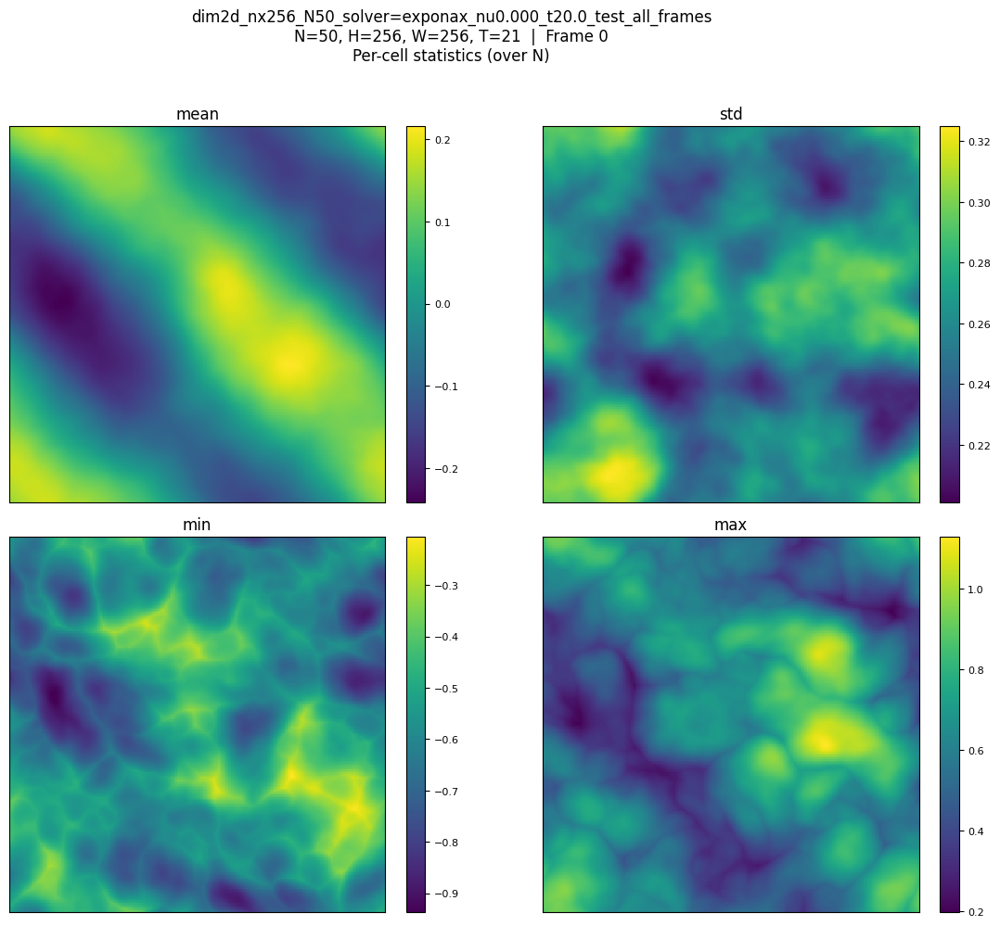

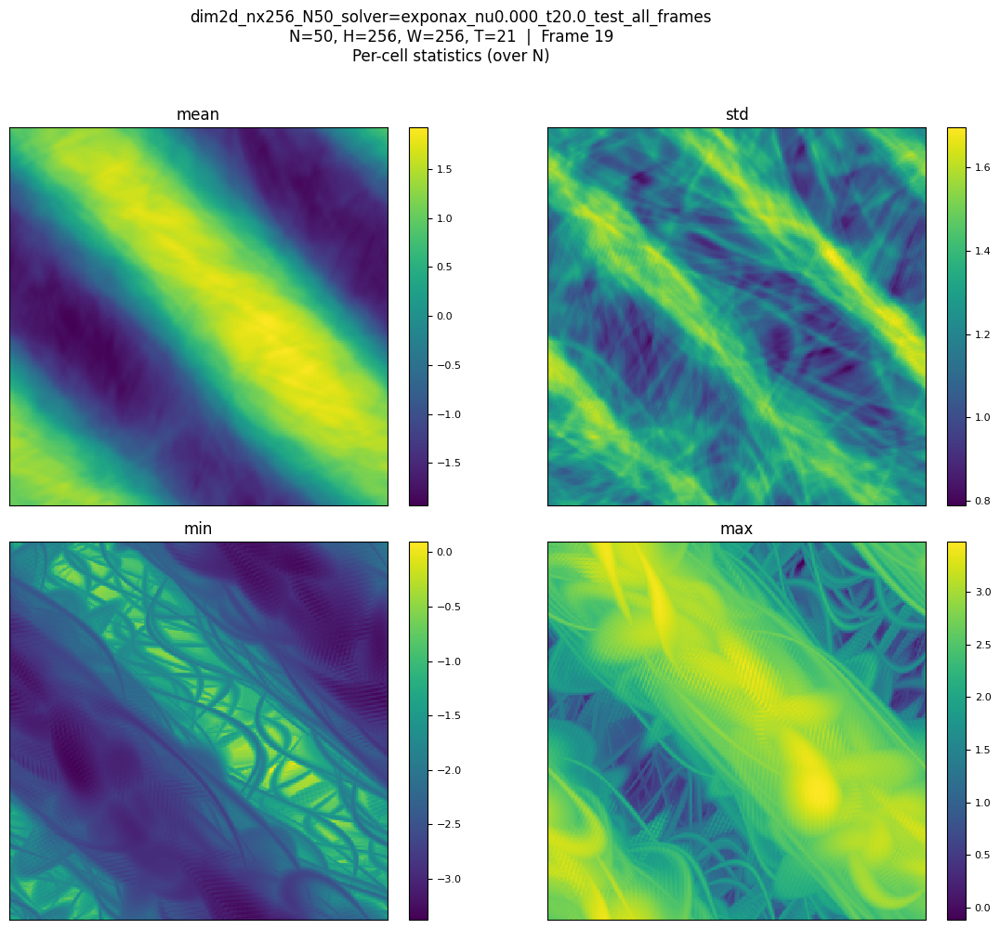

In [2]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt")


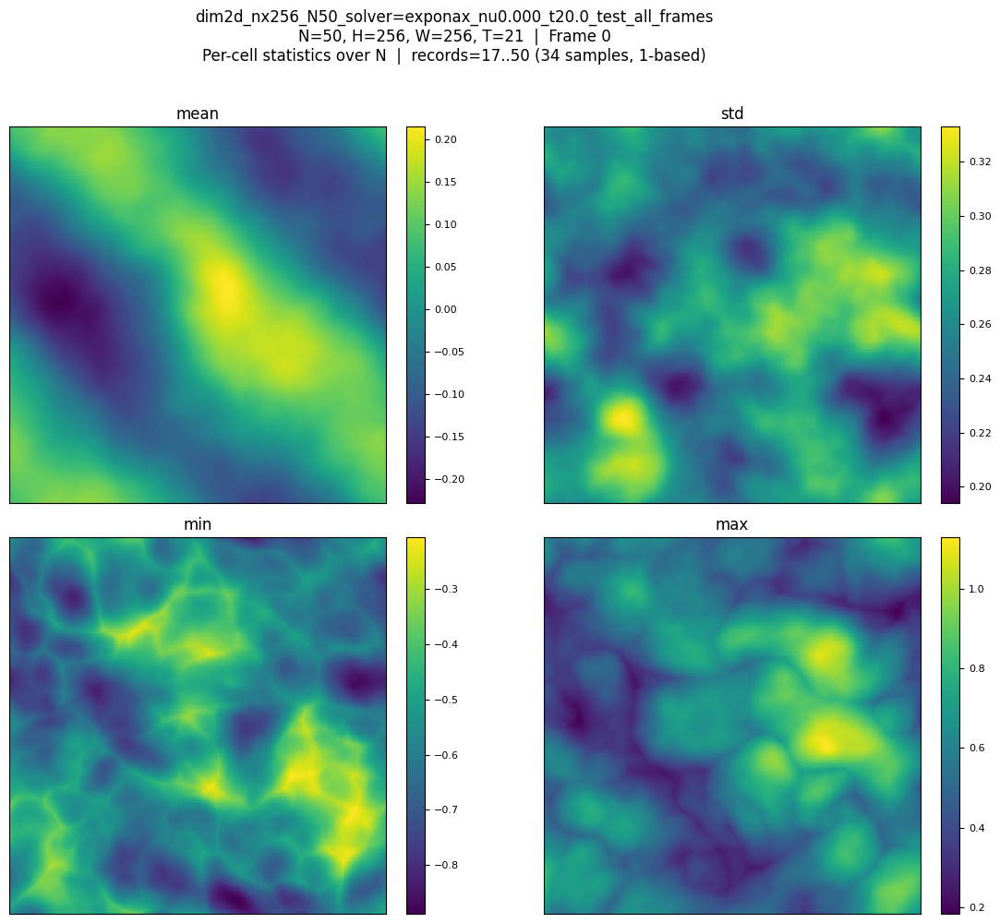

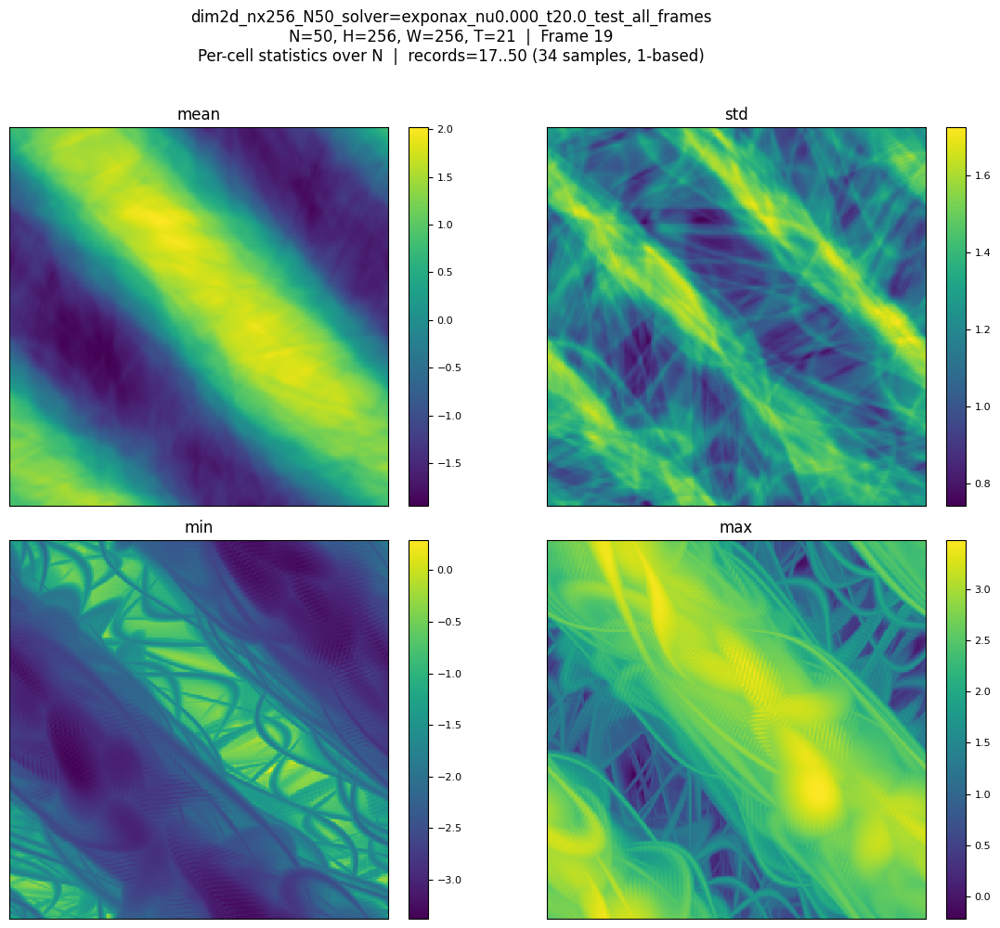

In [4]:
# ---- 在 notebook 里直接运行 ----
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

def _per_cell_stats_from_raw(y_t: torch.Tensor):
    """
    y_t: (N, H, W) torch tensor
    return: dict of HxW numpy arrays: mean, std, min, max
    统计维度是样本维 N。
    """
    if not torch.is_tensor(y_t) or y_t.ndim != 3:
        raise ValueError(f"expect y_t with shape (N,H,W), got {tuple(y_t.shape)}")
    # to numpy
    A = y_t.contiguous().cpu().numpy().astype(np.float64, copy=False)  # (N,H,W)
    N, H, W = A.shape
    A2D = A.reshape(N, H*W)  # (N, H*W)

    mean = np.nanmean(A2D, axis=0).reshape(H, W).astype(np.float32)
    std  = np.nanstd (A2D, axis=0).reshape(H, W).astype(np.float32)
    vmin = np.nanmin(A2D, axis=0).reshape(H, W).astype(np.float32)
    vmax = np.nanmax(A2D, axis=0).reshape(H, W).astype(np.float32)
    return {"mean": mean, "std": std, "min": vmin, "max": vmax}

def _imshow2d(ax, arr, title):
    im = ax.imshow(arr, origin="lower", interpolation="nearest")
    ax.set_title(title, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

def _resolve_indices(N, record_range=None, record_idx=None, one_based=False):
    """
    把用户的记录选择解析为可用于 y_t 的索引数组。
    - record_range=(a,b): 闭区间 [a,b]；当 one_based=True 时按 1-based 解释（即第 a 到第 b 个）。
    - record_idx=[i1,i2,...]: 离散索引集合；当 one_based=True 时会整体减 1。
    返回：np.ndarray[int]，已去重、排序并裁剪到 [0, N-1]。
    """
    if record_idx is not None:
        idx = np.asarray(record_idx, dtype=int)
        if one_based:
            idx = idx - 1
    elif record_range is not None:
        a, b = record_range
        if one_based:
            a, b = a - 1, b - 1
        # 允许 a > b，自动交换
        lo, hi = (a, b) if a <= b else (b, a)
        # 裁剪到合法范围；构造闭区间
        lo = max(0, lo)
        hi = min(N - 1, hi)
        if hi < 0 or lo > N - 1:
            idx = np.array([], dtype=int)
        else:
            idx = np.arange(lo, hi + 1, dtype=int)
    else:
        # 全部样本
        idx = np.arange(N, dtype=int)

    # 去重排序 & 保证在范围内
    idx = np.unique(idx[(idx >= 0) & (idx < N)])
    if idx.size == 0:
        raise ValueError(f"No valid records selected (N={N}).")
    return idx

def show_spatial_percell_stats(pt_path, frames=(0,19),
                               record_range=None, record_idx=None,
                               one_based=False):
    """
    只需提供数据集路径 pt_path（.pt 文件，字典里含 'y' : (N,H,W,T)）。
    可选：
      - record_range=(a,b): 选取第 a..b 个样本（闭区间）。当 one_based=True 时按 1-based 解释。
      - record_idx=[...]   : 选取给定索引集合；one_based=True 时整体减 1。
    将分别“显示”两张图（每个 frame 一张 2×2），不保存。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not isinstance(payload, dict) or "y" not in payload:
        raise ValueError(f"{pt_path.name}: not a dict or missing key 'y'")
    y = payload["y"]
    if not torch.is_tensor(y) or y.ndim != 4:
        raise ValueError(f"{pt_path.name}: y should be (N,H,W,T), got {tuple(y.shape)}")
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    stem = pt_path.stem

    # 解析样本子集索引
    sel_idx = _resolve_indices(N, record_range=record_range,
                               record_idx=record_idx, one_based=one_based)
    N_sel = int(sel_idx.size)

    for t in frames:
        if t < 0 or t >= T:
            print(f"[skip] frame {t} out of range 0..{T-1}")
            continue
        # 先选样本子集，再统计
        y_t = y[sel_idx, :, :, t]  # (N_sel, H, W)
        stats = _per_cell_stats_from_raw(y_t)

        # 两行两列：mean / std / min / max
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        # 标题里写明子集范围
        if record_idx is not None:
            idx_show = sel_idx if not one_based else (sel_idx + 1)
            head_extra = f"records={idx_show.min()}..{idx_show.max()} ({N_sel} samples)"
        elif record_range is not None:
            if one_based:
                # 还原用户视角（1-based 闭区间）
                a,b = record_range
                a,b = (a,b) if a<=b else (b,a)
                head_extra = f"records={a}..{b} ({N_sel} samples, 1-based)"
            else:
                a,b = record_range
                a,b = (a,b) if a<=b else (b,a)
                head_extra = f"records={max(0,a)}..{min(N-1,b)} ({N_sel} samples, 0-based)"
        else:
            head_extra = f"records=all (N={N_sel})"

        title_head = (
            f"{stem}\n"
            f"N={N}, H={H}, W={W}, T={T}  |  Frame {t}\n"
            f"Per-cell statistics over N  |  {head_extra}"
        )
        fig.suptitle(title_head, y=0.995, fontsize=12)

        _imshow2d(axes[0,0], stats["mean"], "mean")
        _imshow2d(axes[0,1], stats["std"],  "std")
        _imshow2d(axes[1,0], stats["min"],  "min")
        _imshow2d(axes[1,1], stats["max"],  "max")

        fig.tight_layout(rect=[0,0,1,0.98])
        plt.show()

# ==== 用法示例 ====
# 1) 全部样本：
# show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt")

# 2) 选“第 17 到第 70 个”（人类习惯 1-based，闭区间）：
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt", 
                           record_range=(17,50), one_based=True)

# 3) 显式索引列表（0-based）：只用样本 0、5、10、11：
# show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_all_frames.pt", record_idx=[0,5,10,11])


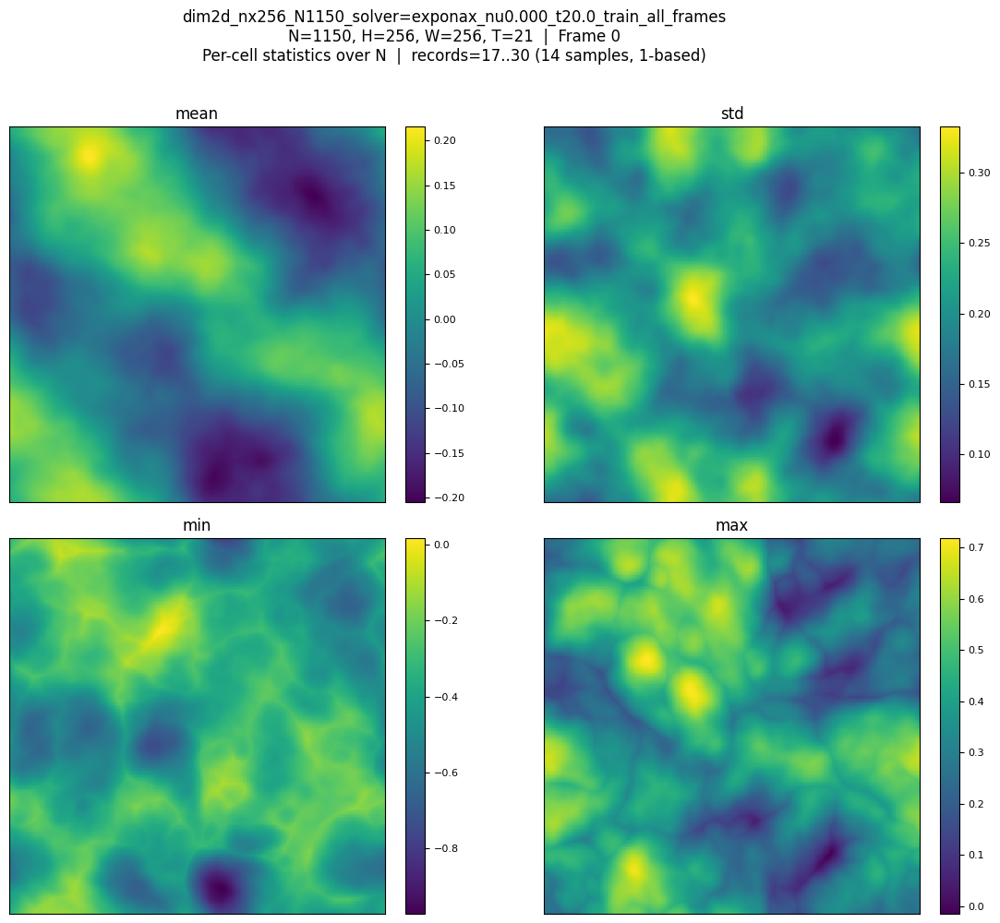

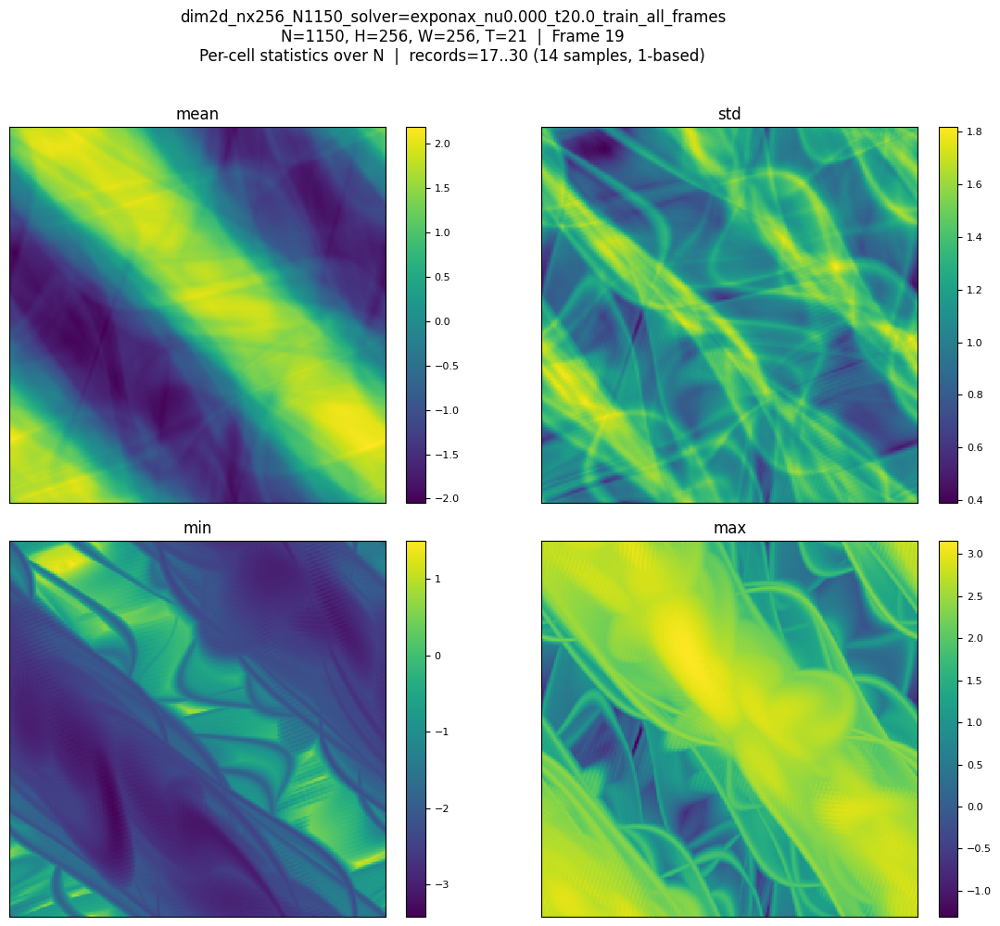

In [6]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,30), one_based=True)

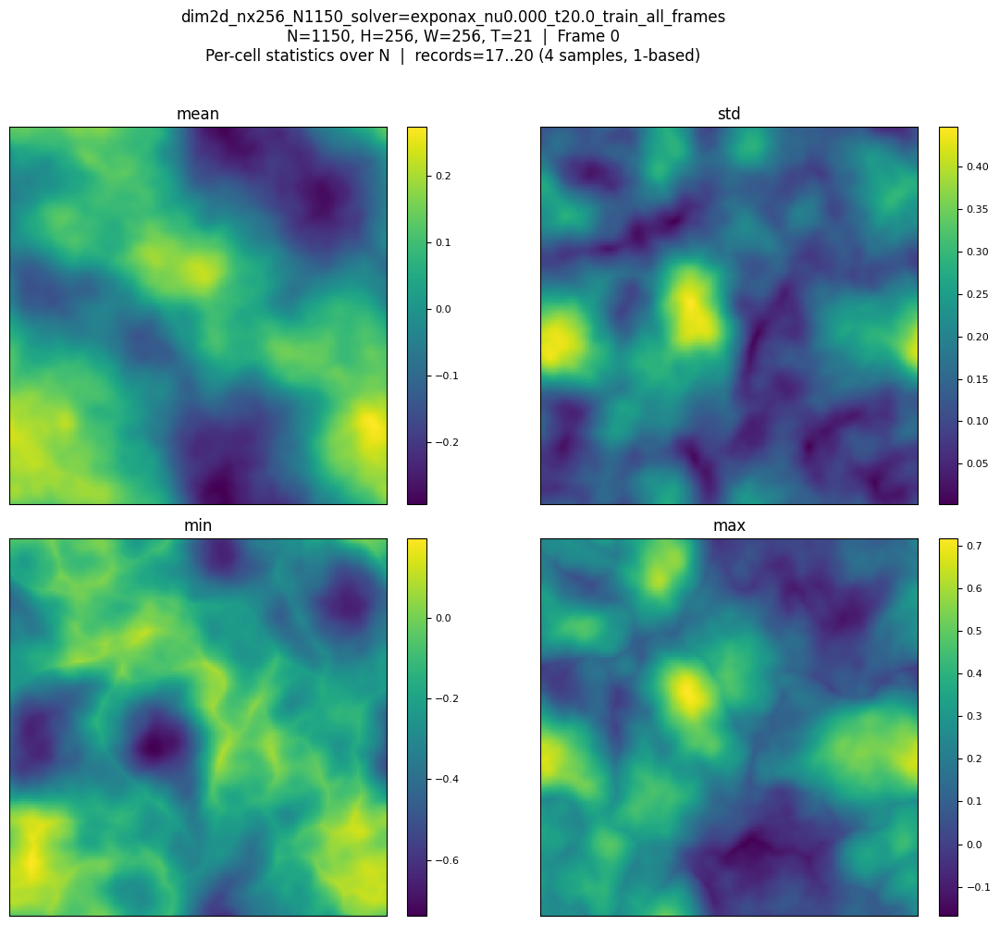

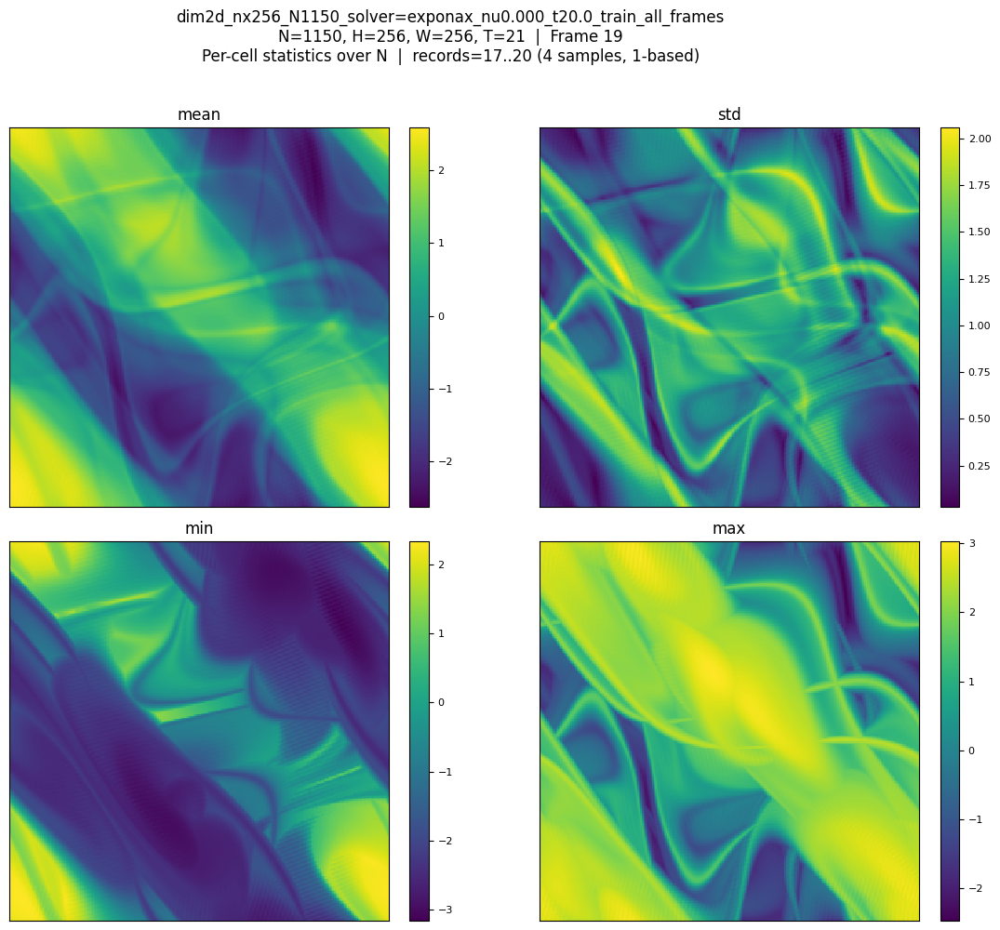

In [7]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,20), one_based=True)

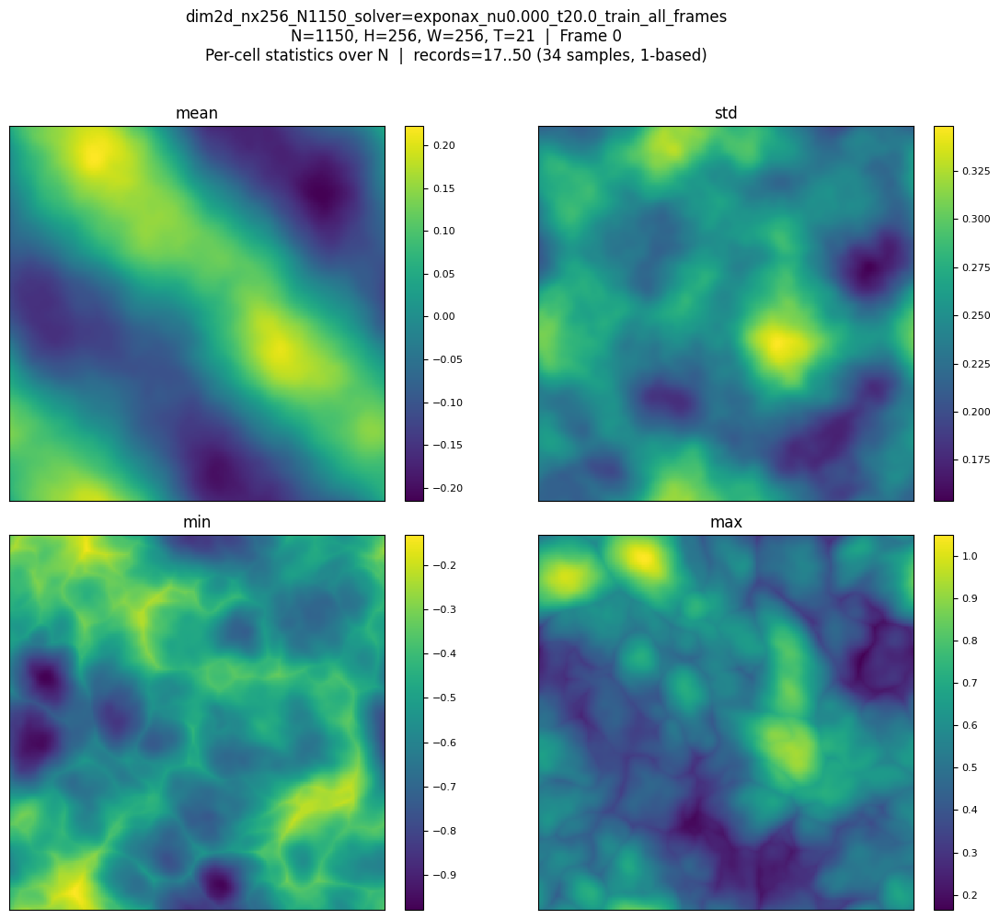

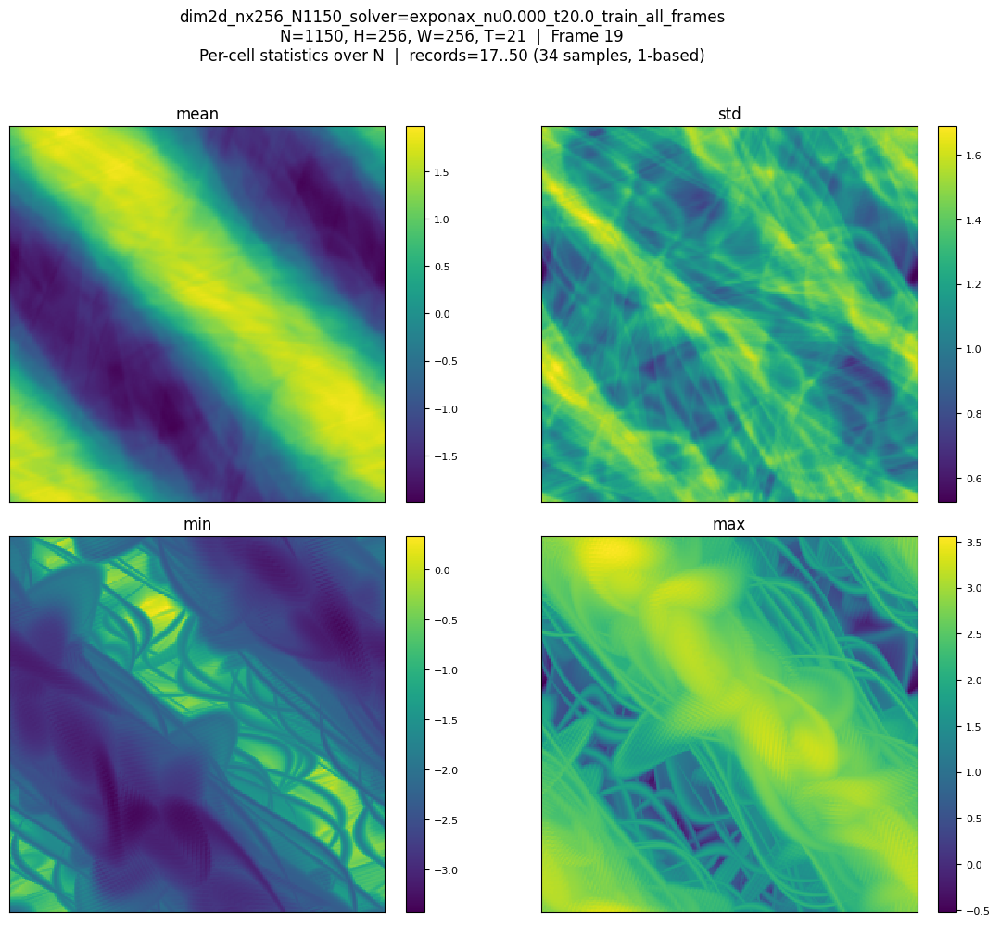

In [5]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,50), one_based=True)

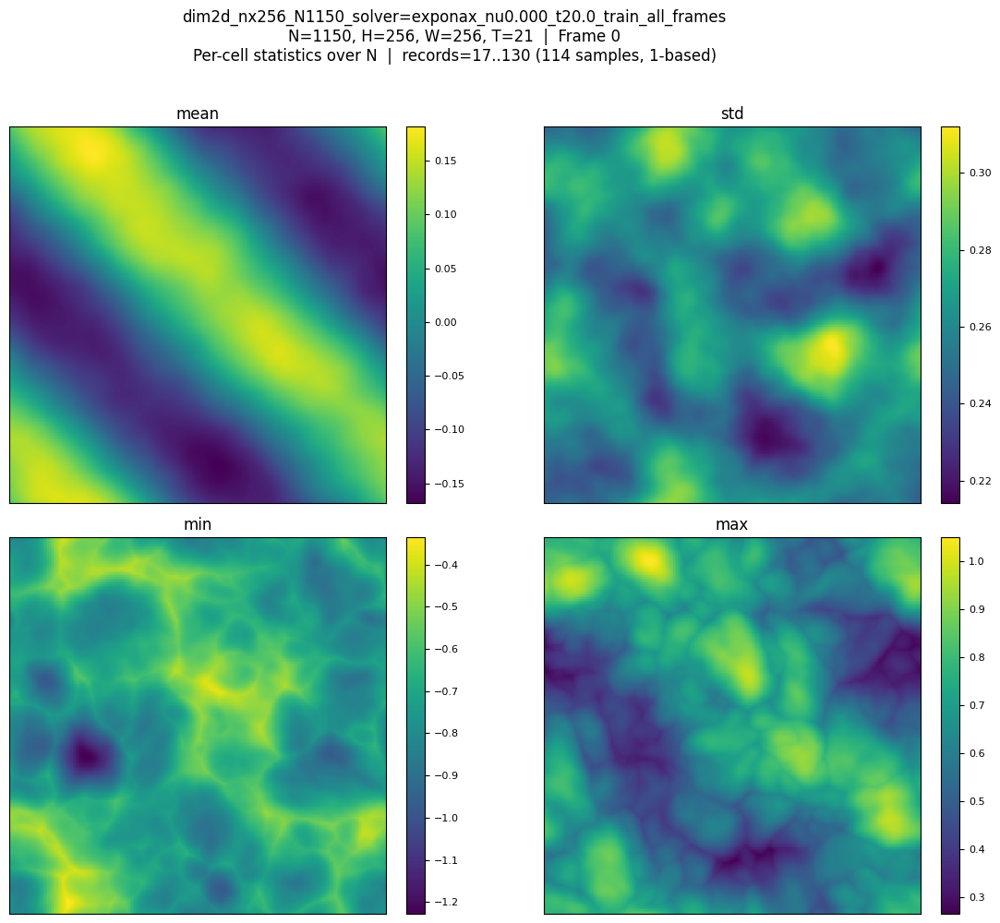

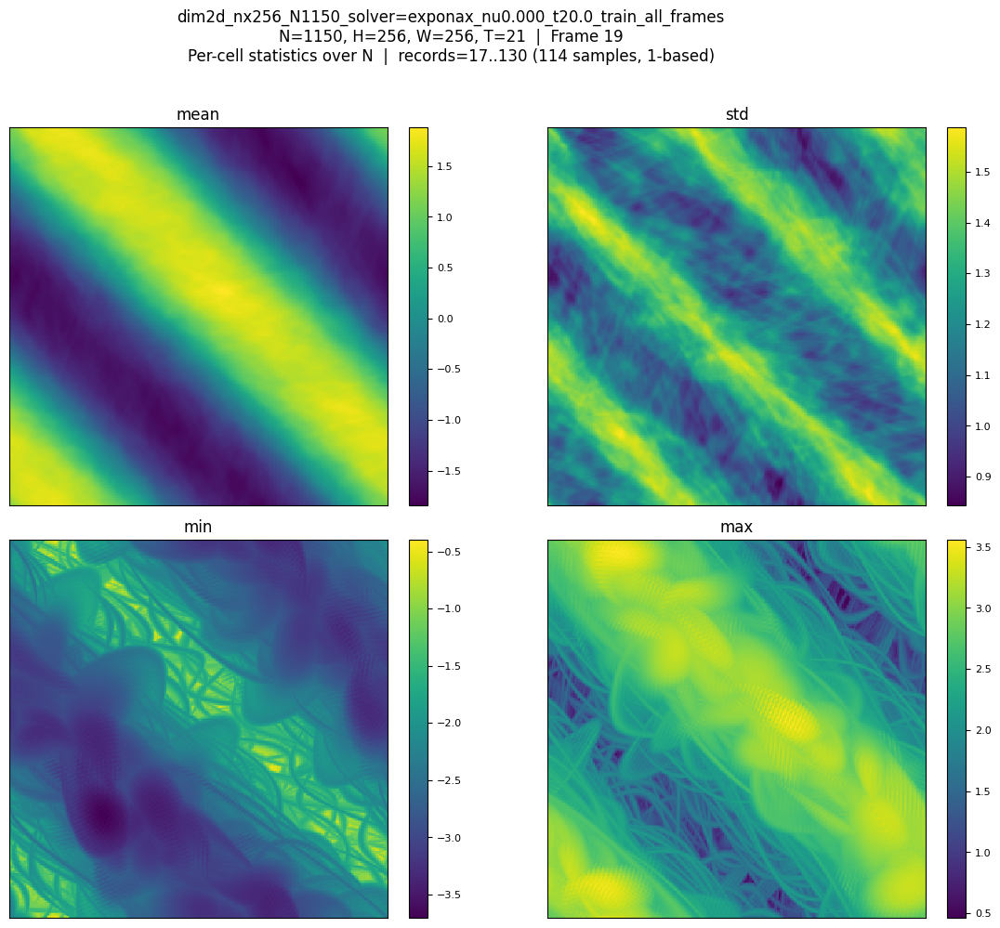

In [8]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,130), one_based=True)

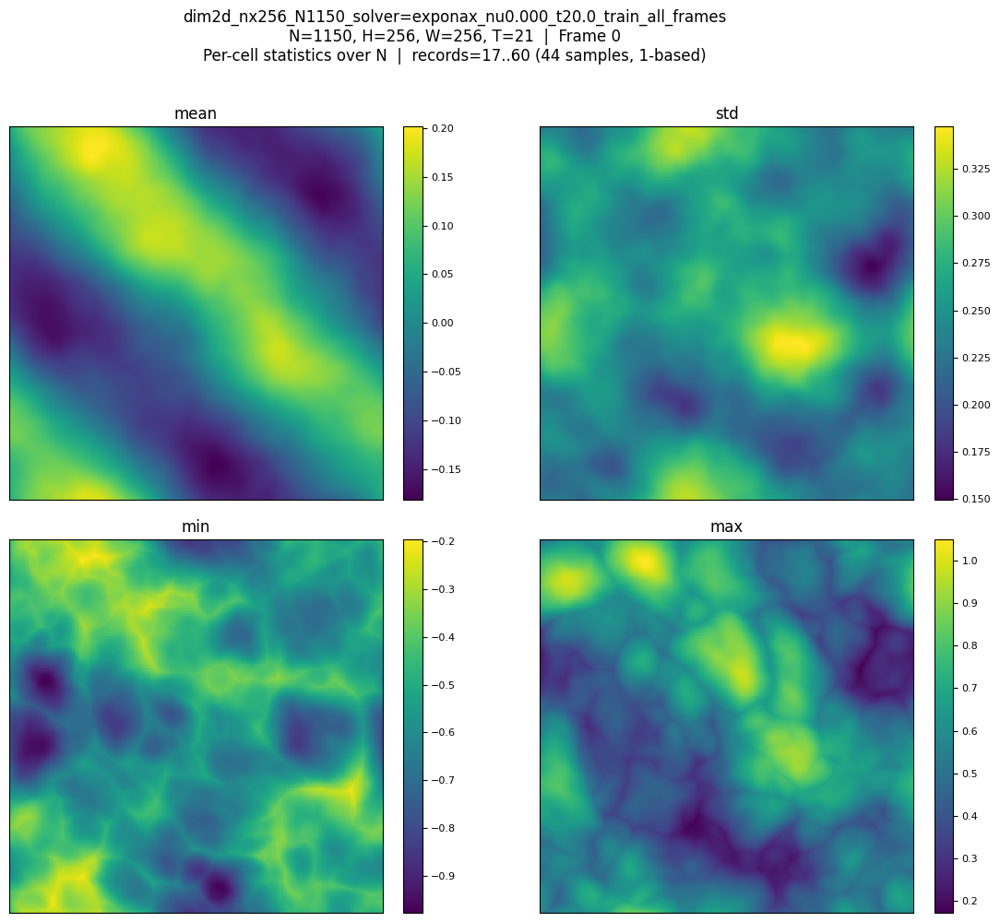

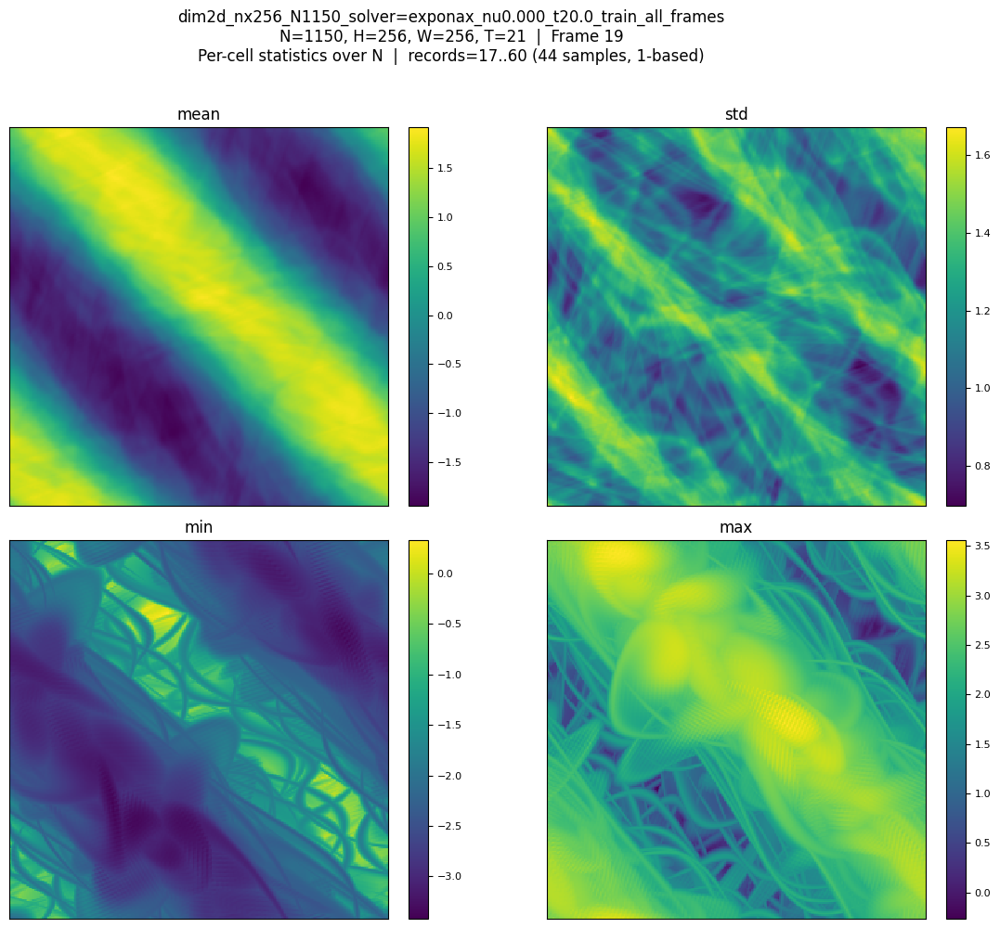

In [9]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,60), one_based=True)

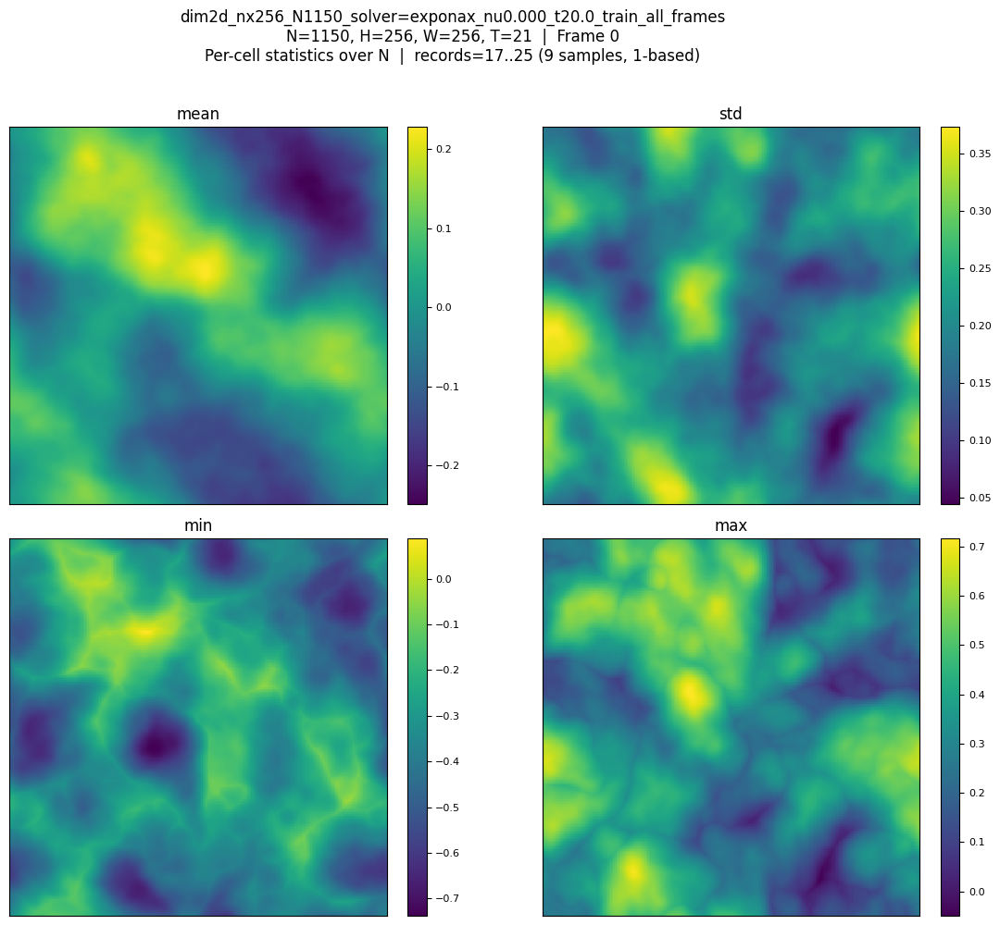

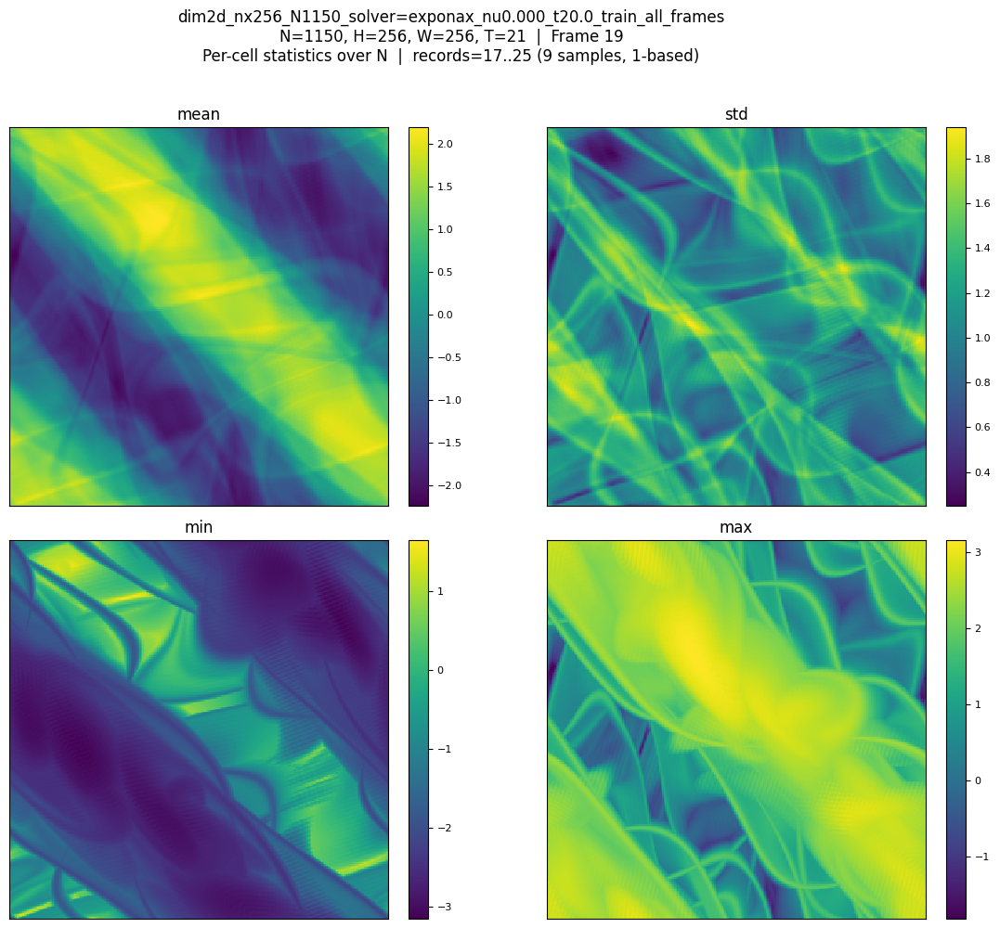

In [10]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,25), one_based=True)

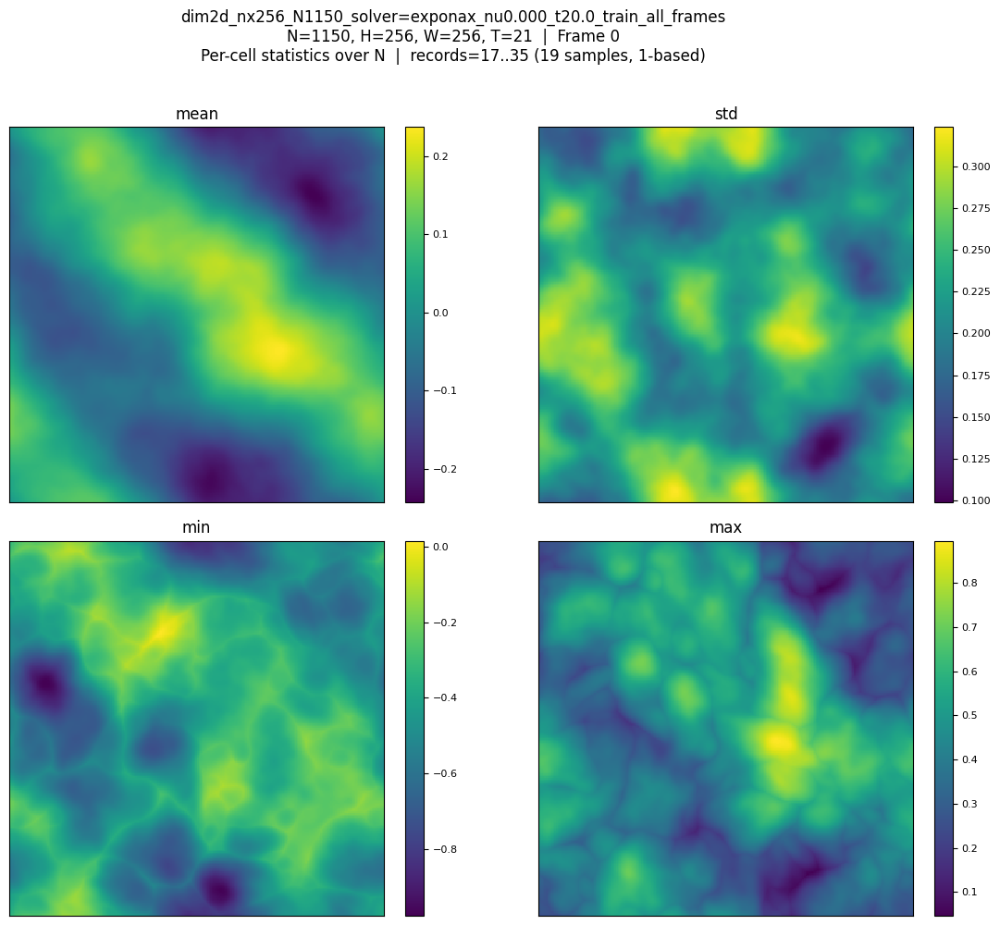

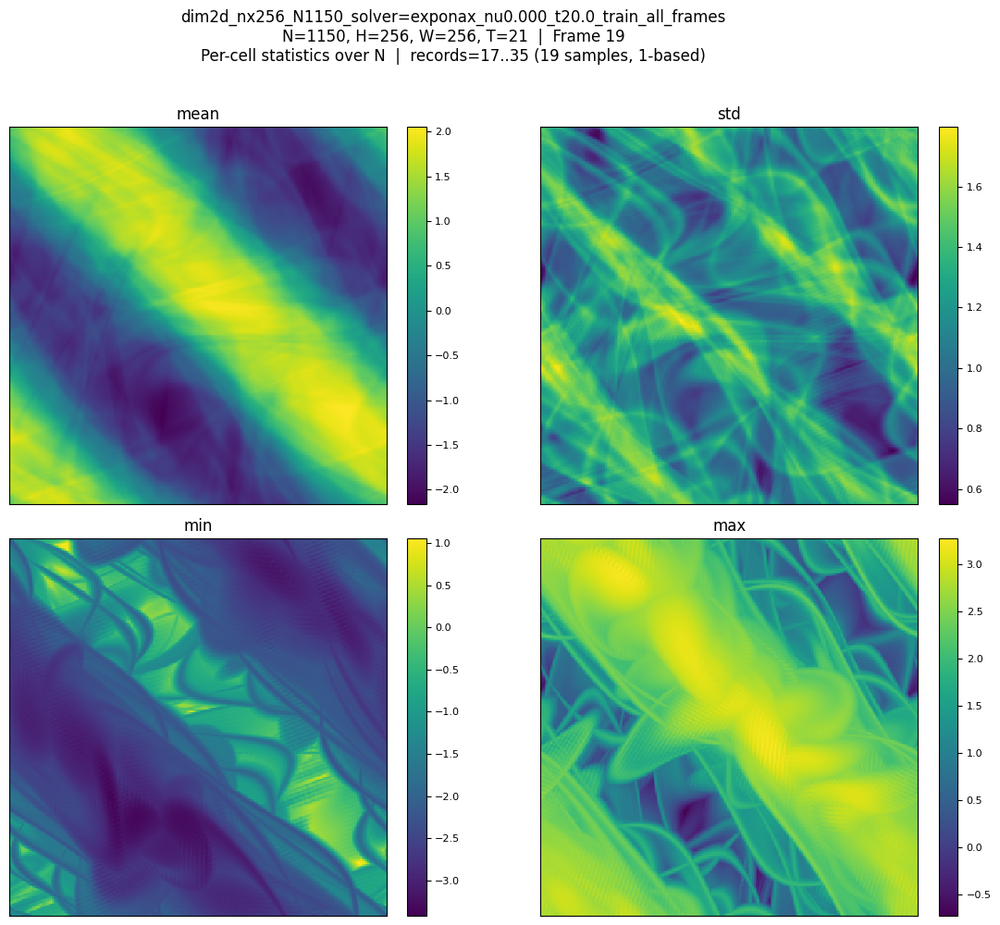

In [15]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,35), one_based=True)

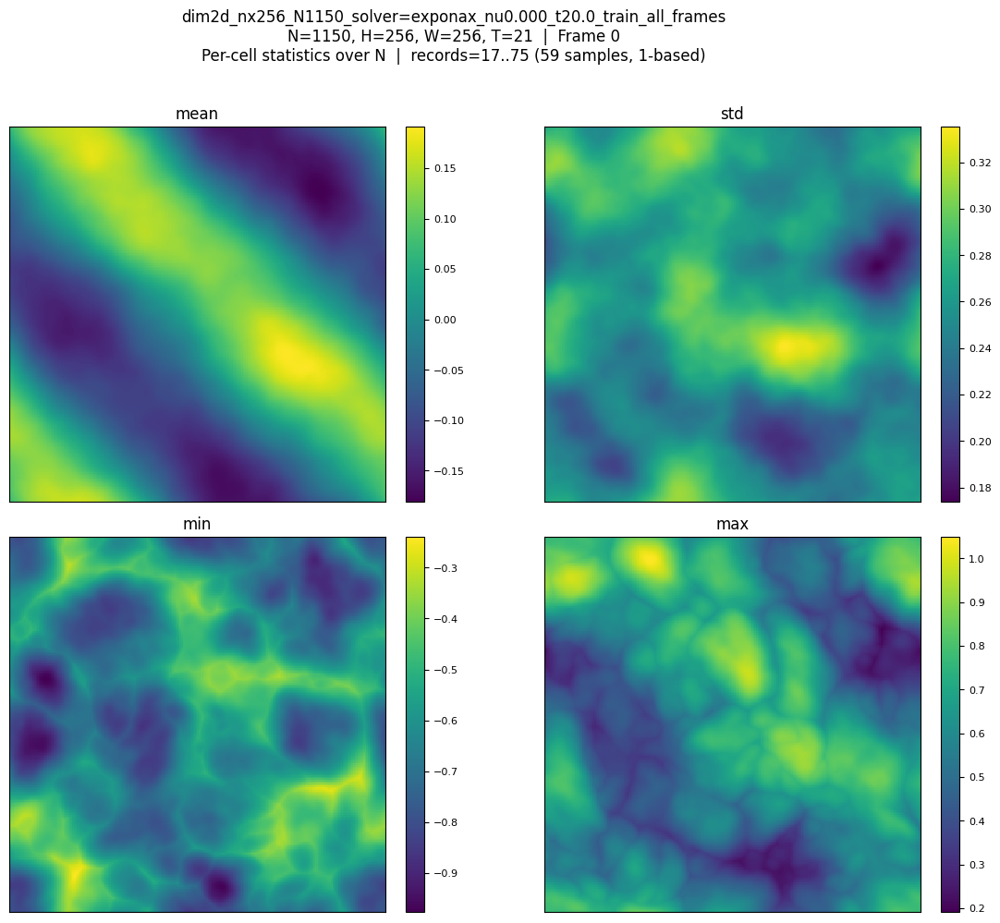

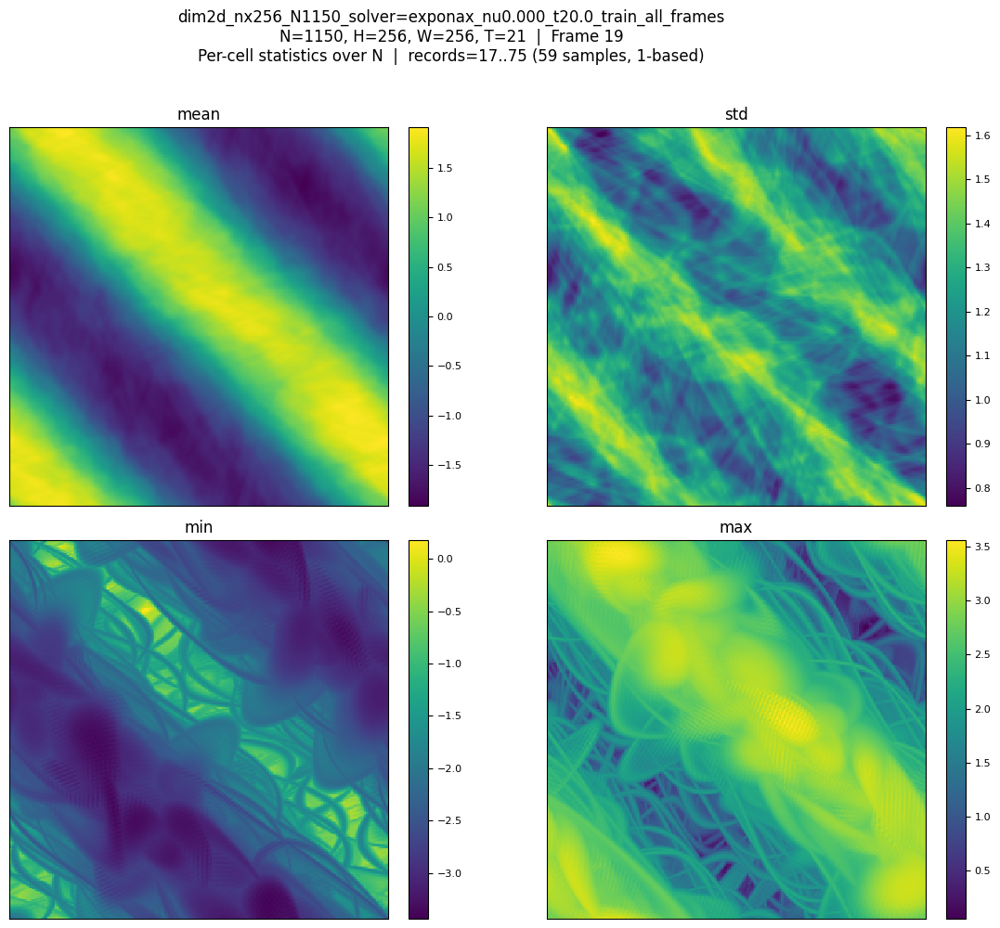

In [16]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,75), one_based=True)

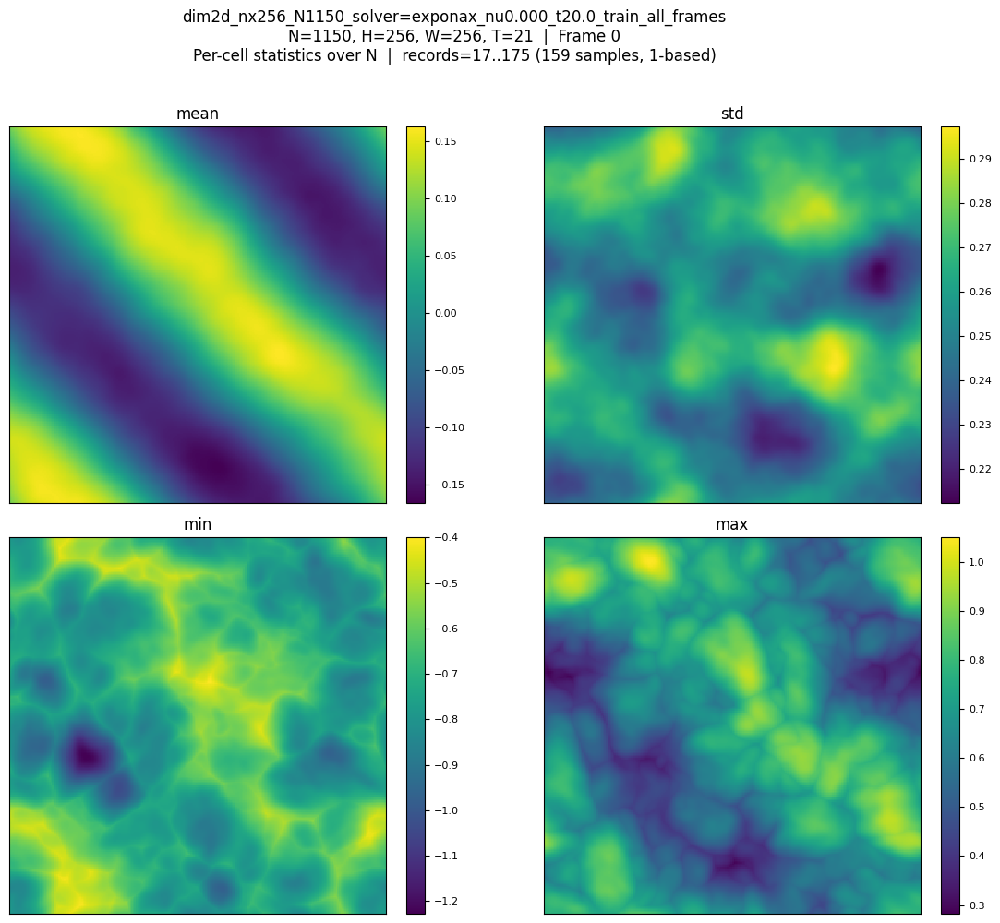

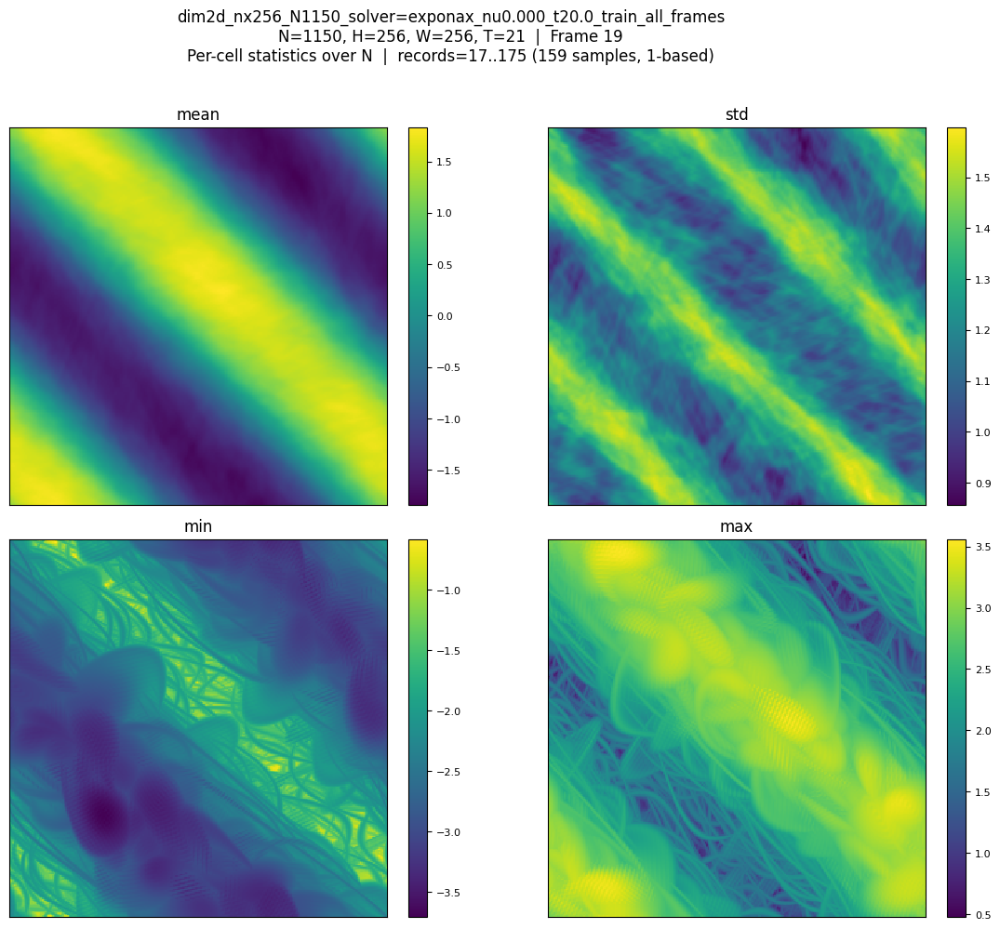

In [17]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=(17,175), one_based=True)

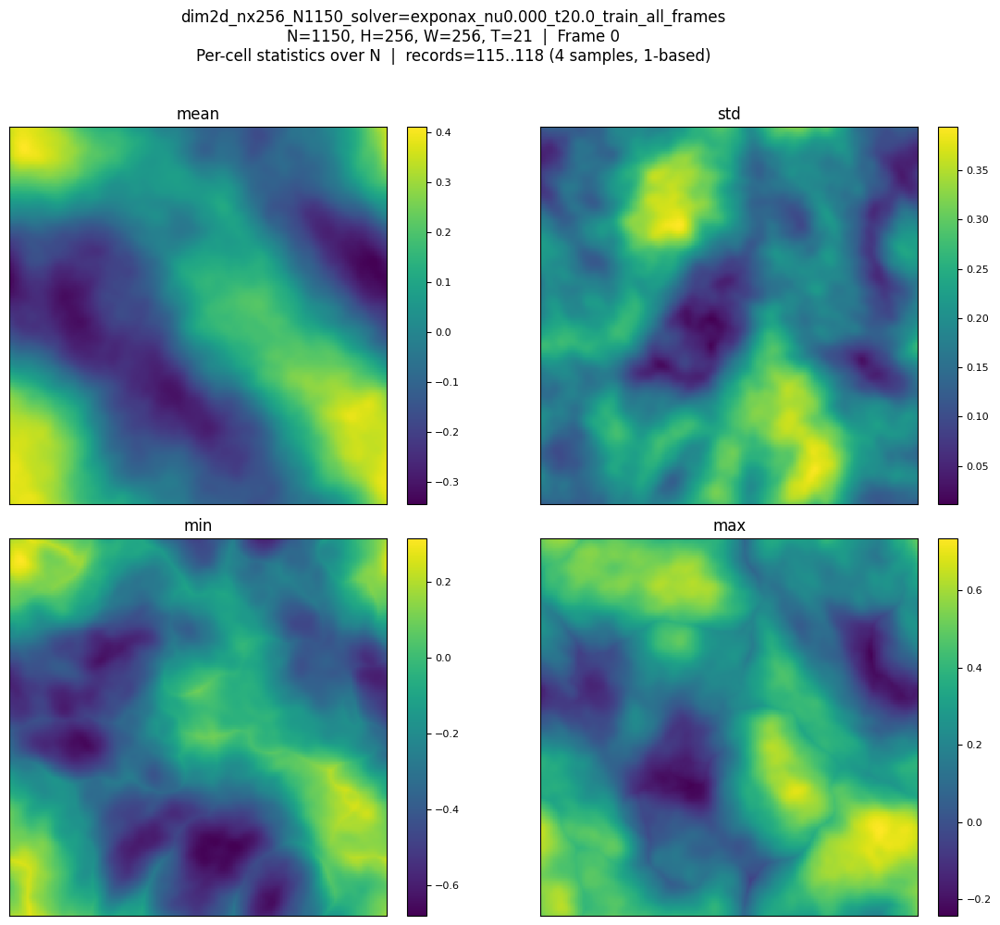

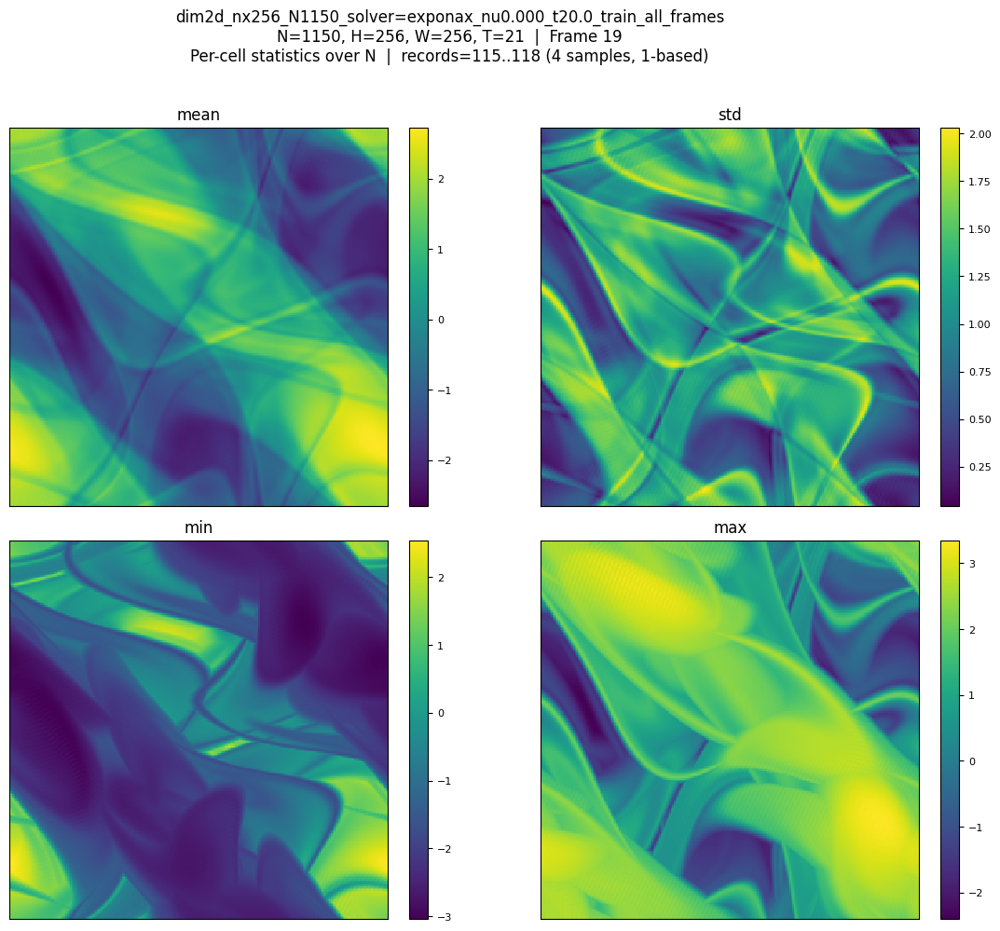

In [18]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=[115, 118], one_based=True)

In [19]:
show_spatial_percell_stats("exponax_datasets/t20/dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pt", 
                           record_range=[115], one_based=True)

ValueError: not enough values to unpack (expected 2, got 1)

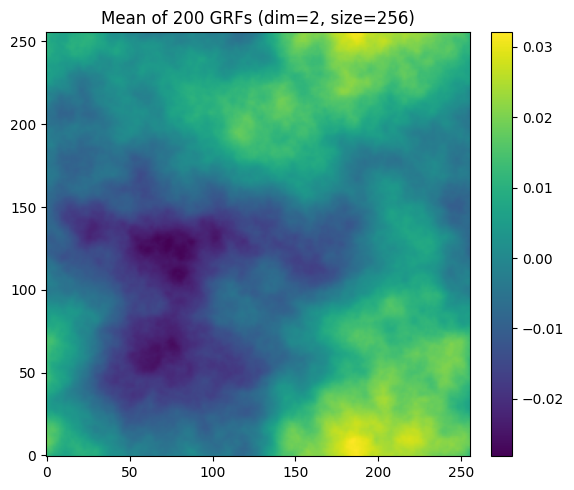

In [11]:
import torch
import math
import matplotlib.pyplot as plt

# ===== 你给的类（保持不变）=====
class GaussianRF(object):
    def __init__(self, dim, size, alpha=2, tau=3, sigma=None, boundary="periodic", device=None):
        self.dim = dim
        self.device = device
        if sigma is None:
            sigma = tau**(0.5*(2*alpha - self.dim))
        k_max = size//2

        if dim == 1:
            k = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                           torch.arange(start=-k_max, end=0, step=1, device=device)), 0)
            self.sqrt_eig = size*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0] = 0.0

        elif dim == 2:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,1)
            k_x = wavenumers.transpose(0,1)
            k_y = wavenumers
            self.sqrt_eig = (size**2)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0] = 0.0

        elif dim == 3:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,size,1)
            k_x = wavenumers.transpose(1,2)
            k_y = wavenumers
            k_z = wavenumers.transpose(0,2)
            self.sqrt_eig = (size**3)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2 + k_z**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0,0] = 0.0

        self.size = tuple([size]*self.dim)

    def sample(self, N):
        coeff = torch.randn(N, *self.size, dtype=torch.cfloat, device=self.device)
        coeff = self.sqrt_eig * coeff
        return torch.fft.ifftn(coeff, dim=list(range(-1, -self.dim - 1, -1))).real

# ===== 工具函数：生成N个样本取平均 =====
@torch.no_grad()
def grf_mean(N, dim=2, size=256, alpha=2, tau=3, sigma=None, device=None, batch_size=32):
    """
    返回形状为:
      1D: (size,)
      2D: (size, size)
      3D: (size, size, size)
    的逐点平均场。
    """
    grf = GaussianRF(dim=dim, size=size, alpha=alpha, tau=tau, sigma=sigma, device=device)
    # 累加用更高精度，减少数值误差
    running_sum = None

    left = N
    while left > 0:
        b = min(batch_size, left)
        x = grf.sample(b)  # (b, *size)
        if running_sum is None:
            running_sum = x.sum(dim=0, dtype=torch.float64)
        else:
            running_sum += x.sum(dim=0, dtype=torch.float64)
        left -= b

    mean_field = (running_sum / N).to('cpu').to(torch.float32)
    return mean_field  # 1D/2D/3D tensor

# ===== 画图（按维度自适应）=====
def plot_mean(mean_field, dim, slice_axis=2, slice_index=None, title=None):
    """
    dim=1: 折线
    dim=2: 热力图
    dim=3: 默认沿 slice_axis 取中间切片（或指定 slice_index）
    """
    if dim == 1:
        plt.figure(figsize=(8,3))
        plt.plot(mean_field.numpy())
        plt.xlabel('x')
        plt.ylabel('mean')
        plt.title(title or 'Mean of GRF (1D)')
        plt.tight_layout()
        plt.show()

    elif dim == 2:
        plt.figure(figsize=(6,5))
        im = plt.imshow(mean_field.numpy(), origin='lower', aspect='equal')
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.title(title or 'Mean of GRF (2D)')
        plt.tight_layout()
        plt.show()

    elif dim == 3:
        S = mean_field.shape[0]
        if slice_index is None:
            slice_index = S // 2
        if slice_axis == 0:
            sl = mean_field[slice_index, :, :].numpy()
            axlbl = f'x={slice_index}'
        elif slice_axis == 1:
            sl = mean_field[:, slice_index, :].numpy()
            axlbl = f'y={slice_index}'
        else:
            sl = mean_field[:, :, slice_index].numpy()
            axlbl = f'z={slice_index}'

        plt.figure(figsize=(6,5))
        im = plt.imshow(sl, origin='lower', aspect='equal')
        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.title(title or f'Mean of GRF (3D slice, {axlbl})')
        plt.tight_layout()
        plt.show()

# ===== 示例用法 =====
if __name__ == '__main__':
    # 你可以改这里的 N、dim、size 等参数
    N   = 200          # <<=== 你想要的样本数
    dim = 2            # 1 / 2 / 3
    size = 256
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    mean_field = grf_mean(N=N, dim=dim, size=size, alpha=2, tau=3, sigma=None,
                          device=device, batch_size=32)
    plot_mean(mean_field, dim=dim, title=f'Mean of {N} GRFs (dim={dim}, size={size})')


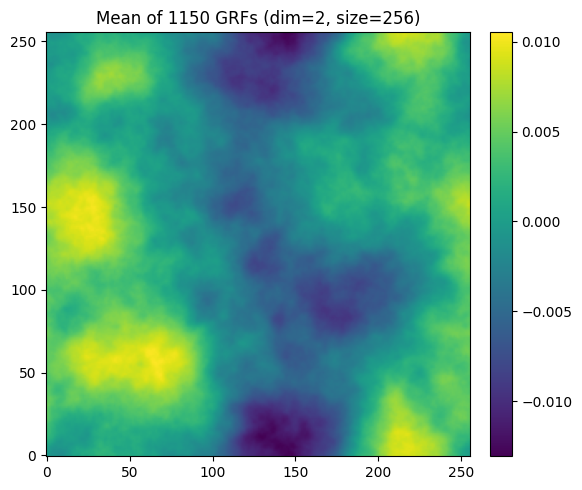

In [12]:
# 你可以改这里的 N、dim、size 等参数
N   = 1150          # <<=== 你想要的样本数
dim = 2            # 1 / 2 / 3
size = 256
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mean_field = grf_mean(N=N, dim=dim, size=size, alpha=2, tau=3, sigma=None,
                        device=device, batch_size=32)
plot_mean(mean_field, dim=dim, title=f'Mean of {N} GRFs (dim={dim}, size={size})')

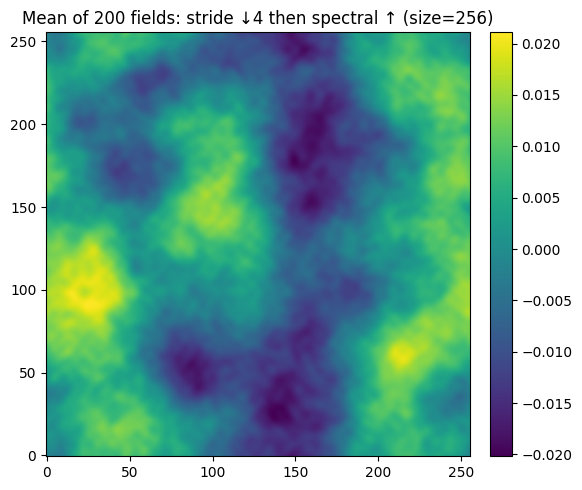

In [13]:
import torch
import math
import matplotlib.pyplot as plt

# ===== 你的 GRF 类：原样保留 =====
class GaussianRF(object):
    def __init__(self, dim, size, alpha=2, tau=3, sigma=None, boundary="periodic", device=None):
        self.dim = dim
        self.device = device
        if sigma is None:
            sigma = tau**(0.5*(2*alpha - self.dim))
        k_max = size//2

        if dim == 1:
            k = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                           torch.arange(start=-k_max, end=0, step=1, device=device)), 0)
            self.sqrt_eig = size*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0] = 0.0

        elif dim == 2:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,1)
            k_x = wavenumers.transpose(0,1)
            k_y = wavenumers
            self.sqrt_eig = (size**2)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0] = 0.0

        elif dim == 3:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,size,1)
            k_x = wavenumers.transpose(1,2)
            k_y = wavenumers
            k_z = wavenumers.transpose(0,2)
            self.sqrt_eig = (size**3)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2 + k_z**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0,0] = 0.0

        self.size = tuple([size]*self.dim)

    def sample(self, N):
        coeff = torch.randn(N, *self.size, dtype=torch.cfloat, device=self.device)
        coeff = self.sqrt_eig * coeff
        return torch.fft.ifftn(coeff, dim=list(range(-1, -self.dim - 1, -1))).real


# ===== 频域零填充上采样（保留你的幅度校正）=====
def spectral_upsample(field: torch.Tensor, target_size: int = 256):
    """
    field: (..., H, W) 实值
    return: (..., target_size, target_size)
    """
    *batch_dims, H, W = field.shape
    assert target_size >= H and target_size >= W, "目标尺寸必须大于输入尺寸"
    dev = field.device

    freq = torch.fft.fft2(field, norm='ortho')
    freq_shifted = torch.fft.fftshift(freq, dim=(-2, -1))

    pad_H = (target_size - H) // 2
    pad_W = (target_size - W) // 2

    new_freq_shifted = torch.zeros(
        (*batch_dims, target_size, target_size),
        dtype=freq_shifted.dtype, device=dev
    )
    new_freq_shifted[..., pad_H:pad_H+H, pad_W:pad_W+W] = freq_shifted

    new_freq = torch.fft.ifftshift(new_freq_shifted, dim=(-2, -1))
    upsampled = torch.fft.ifft2(new_freq, norm='ortho')

    # 保持常数场幅度不变（方阵情形）：scale = target/H
    return (target_size / H) * upsampled.real


# ===== 直接抽样下采样（不是频域）：[::4, ::4] =====
def stride_downsample(field: torch.Tensor, factor: int = 4):
    """
    field: (..., H, W)
    return: (..., H//factor, W//factor)
    """
    return field[..., ::factor, ::factor]


# ===== 主流程：生成→下采样→频域上采样→平均→画图 =====
@torch.no_grad()
def mean_after_down_up(N=200, size=256, factor=4, batch_size=32, device=None):
    assert size % factor == 0, "size 必须能被 factor 整除"
    small = size // factor

    grf = GaussianRF(dim=2, size=size, device=device)
    running_sum = None
    left = N

    while left > 0:
        b = min(batch_size, left)
        x = grf.sample(b)                               # (b, 256, 256)
        x_ds = stride_downsample(x, factor=factor)      # (b, 64, 64)
        x_up = spectral_upsample(x_ds, target_size=size)  # (b, 256, 256)

        if running_sum is None:
            running_sum = x_up.sum(dim=0, dtype=torch.float64)
        else:
            running_sum += x_up.sum(dim=0, dtype=torch.float64)
        left -= b

    mean_field = (running_sum / N).to('cpu').to(torch.float32)
    return mean_field


def show_mean(mean_field, title="Mean after stride↓ then spectral↑"):
    plt.figure(figsize=(6,5))
    im = plt.imshow(mean_field.numpy(), origin='lower', aspect='equal')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    N = 200            # 你想要的样本数
    size = 256
    factor = 4

    mean_field = mean_after_down_up(N=N, size=size, factor=factor, batch_size=32, device=device)
    show_mean(mean_field, title=f"Mean of {N} fields: stride ↓{factor} then spectral ↑ (size={size})")


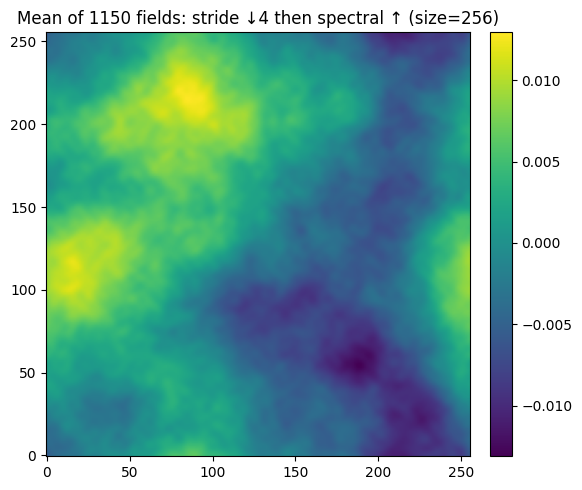

In [14]:
N = 1150            # 你想要的样本数
size = 256
factor = 4

mean_field = mean_after_down_up(N=N, size=size, factor=factor, batch_size=32, device=device)
show_mean(mean_field, title=f"Mean of {N} fields: stride ↓{factor} then spectral ↑ (size={size})")